# Importing Libraries

In [144]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loading the datasets

In [145]:
orders = pd.read_csv(r"olist_orders_dataset.csv")
customers = pd.read_csv(r"olist_customers_dataset.csv")
geolocation = pd.read_csv(r"olist_geolocation_dataset.csv")
order_items = pd.read_csv(r"olist_order_items_dataset.csv")
order_payment = pd.read_csv(r"olist_order_payments_dataset.csv")
order_review = pd.read_csv(r"olist_order_reviews_dataset.csv")
products = pd.read_csv(r"olist_products_dataset.csv")
sellers = pd.read_csv(r"olist_sellers_dataset.csv")
product_category_translation = pd.read_csv(r"product_category_name_translation.csv")

# Converting into DataFrames


In [146]:
df_orders = pd.DataFrame(orders)
df_customers = pd.DataFrame(customers)
df_geolocation = pd.DataFrame(geolocation)
df_order_items = pd.DataFrame(order_items)
df_order_payment = pd.DataFrame(order_payment)
df_order_review = pd.DataFrame(order_review)
df_products = pd.DataFrame(products)
df_sellers = pd.DataFrame(sellers)
df_product_category_translation = pd.DataFrame(product_category_translation)


# Finding mean of latitudes and longitudes having same zip code

In [147]:
lat = df_geolocation.groupby("geolocation_zip_code_prefix")["geolocation_lat"].mean()
lng  = df_geolocation.groupby("geolocation_zip_code_prefix")["geolocation_lng"].mean()

df_clean_geolocation = pd.DataFrame({
    'geolocation_zip_code_prefix' : lat.index,
    'geolocation_lat' : lat.values,
    'geolocation_lng' : lng.values,
   
})

# Merging the datasets into 1 dataset

In [148]:
df_merge1 = pd.merge(df_orders,df_customers, on="customer_id", how="left")

In [149]:
df_merge2 = pd.merge(df_merge1, df_clean_geolocation, left_on="customer_zip_code_prefix", right_on="geolocation_zip_code_prefix", how="left")

In [150]:
df_merge3 = pd.merge(df_merge2, df_order_items, on="order_id", how="left")

In [151]:
df_merge4 = pd.merge(df_merge3, df_order_payment, on="order_id", how="left")

In [152]:
df_merge5 = pd.merge(df_merge4, df_order_review, on="order_id", how="left")

In [153]:
df_merge6 = pd.merge(df_merge5, df_products, on="product_id", how="left")

In [154]:
df_merge7 = pd.merge(df_merge6, df_sellers, on="seller_id", how="left")

In [155]:
df = pd.merge(df_merge7, df_product_category_translation, on="product_category_name", how="left")

# Information about the dataset

In [156]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 43 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       119143 non-null  object 
 1   customer_id                    119143 non-null  object 
 2   order_status                   119143 non-null  object 
 3   order_purchase_timestamp       119143 non-null  object 
 4   order_approved_at              118966 non-null  object 
 5   order_delivered_carrier_date   117057 non-null  object 
 6   order_delivered_customer_date  115722 non-null  object 
 7   order_estimated_delivery_date  119143 non-null  object 
 8   customer_unique_id             119143 non-null  object 
 9   customer_zip_code_prefix       119143 non-null  int64  
 10  customer_city                  119143 non-null  object 
 11  customer_state                 119143 non-null  object 
 12  geolocation_zip_code_prefix   

# Droping the column geolocation_zip_code_prefix 

In [157]:
df = df.drop(columns='geolocation_zip_code_prefix')

# Descriptive Statistics 

In [158]:
df.describe()

,customer_zip_code_prefix,geolocation_lat,geolocation_lng,order_item_id,price,freight_value,payment_sequential,payment_installments,payment_value,review_score,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix
count,119143.000000,118821.000000,118821.000000,118310.000000,118310.000000,118310.000000,119140.000000,119140.000000,119140.000000,118146.000000,116601.000000,116601.000000,116601.000000,118290.000000,118290.000000,118290.000000,118290.000000,118310.000000
mean,35033.451298,-21.230187,-46.191214,1.196543,120.646603,20.032387,1.094737,2.941246,172.735135,4.015582,48.767498,785.967822,2.205161,2112.250740,30.265145,16.619706,23.074799,24442.410413
std,29823.198969,5.564179,4.042785,0.699489,184.109691,15.836850,0.730141,2.777848,267.776077,1.400436,10.033540,652.584121,1.717452,3786.695111,16.189367,13.453584,11.749139,27573.004511
min,1003.000000,-33.689948,-72.668881,1.000000,0.850000,0.000000,1.000000,0.000000,0.000000,1.000000,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000,1001.000000
25%,11250.000000,-23.589488,-48.097776,1.000000,39.900000,13.080000,1.000000,1.000000,60.850000,4.000000,42.000000,346.000000,1.000000,300.000000,18.000000,8.000000,15.000000,6429.000000
50%,24240.000000,-22.928413,-46.631239,1.000000,74.900000,16.280000,1.000000,2.000000,108.160000,5.000000,52.000000,600.000000,1.000000,700.000000,25.000000,13.000000,20.000000,13660.000000
75%,58475.000000,-20.180863,-43.608100,1.000000,134.900000,21.180000,1.000000,4.000000,189.240000,5.000000,57.000000,983.000000,3.000000,1800.000000,38.000000,20.000000,30.000000,27972.000000
max,99990.000000,42.184003,-8.723762,21.000000,6735.000000,409.680000,29.000000,24.000000,13664.080000,5.000000,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000,99730.000000


# Finding the total no.of null values in each column

In [159]:
df.isnull().sum()

order_id                              0
customer_id                           0
order_status                          0
order_purchase_timestamp              0
order_approved_at                   177
order_delivered_carrier_date       2086
order_delivered_customer_date      3421
order_estimated_delivery_date         0
customer_unique_id                    0
customer_zip_code_prefix              0
customer_city                         0
customer_state                        0
geolocation_lat                     322
geolocation_lng                     322
order_item_id                       833
product_id                          833
seller_id                           833
shipping_limit_date                 833
price                               833
freight_value                       833
payment_sequential                    3
payment_type                          3
payment_installments                  3
payment_value                         3
review_id                           997


# Handling missing values of the column 'order_approved_at'

In [160]:

null = df[df['order_approved_at'].isnull()]
null[['order_approved_at','order_status','order_delivered_carrier_date','order_delivered_customer_date','product_id','shipping_limit_date']]

#removed the rows where order_approved_at is null and order_status is canceled 
df = df[~((df['order_approved_at'].isnull()) & (df['order_status'] == 'canceled'))] 

null[['order_approved_at','order_status','order_delivered_carrier_date','order_delivered_customer_date','product_id','shipping_limit_date']]

#removed the rows where order_approved_at is null and order_status is created 
df = df[~((df['order_approved_at'].isnull()) & (df['order_status'] == 'created'))] 

null[['order_approved_at','order_status','order_delivered_carrier_date','order_delivered_customer_date','product_id','shipping_limit_date']]

,order_approved_at,order_status,order_delivered_carrier_date,order_delivered_customer_date,product_id,shipping_limit_date
1362,NaN,canceled,NaN,NaN,NaN,NaN
2142,NaN,canceled,NaN,NaN,NaN,NaN
2232,NaN,canceled,NaN,NaN,NaN,NaN
2429,NaN,canceled,NaN,NaN,NaN,NaN
2586,NaN,canceled,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
116985,NaN,canceled,NaN,NaN,NaN,NaN
117882,NaN,canceled,NaN,NaN,NaN,NaN
118476,NaN,canceled,NaN,NaN,NaN,NaN
118946,NaN,canceled,NaN,NaN,NaN,NaN


# Handling missing values of the column 'order_delivered_carrier_date'

In [161]:

null = df[df['order_delivered_carrier_date'].isnull()]
null[['order_purchase_timestamp','order_approved_at','order_status','order_delivered_carrier_date','order_delivered_customer_date','order_estimated_delivery_date','shipping_limit_date']]

#removed the rows where order_approved_at is null and order_status is unavailable 
df = df[~((df['order_delivered_carrier_date'].isnull()) & (df['order_status'] == 'unavailable'))]

# replacing order_delivered date to be 'order canceled' where status is cancelled 
df.loc[(df['order_status'] == 'canceled') & (df['order_delivered_carrier_date'].isnull()), ['order_delivered_carrier_date','order_delivered_customer_date']] = 'order canceled'

df[df['order_delivered_carrier_date'] == 'order canceled']


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,product_category_name_english
470,1b9ecfe83cdc259250e1a8aca174f0ad,6d6b50b66d79f80827b6d96751528d30,canceled,2018-08-04 14:29:27,2018-08-07 04:10:26,order canceled,order canceled,2018-08-14 00:00:00,8ea097b1824dbd4d17af71b0afe04301,5514,...,1321.0,3.0,350.0,22.0,11.0,17.0,12215.0,sao jose dos campos,SP,computers_accessories
2156,0966b61e30c4a07edbd7523f59b3f3e4,2fcc597b8934d99715dbfff7909dd27f,canceled,2018-05-22 18:50:55,2018-05-22 19:17:15,order canceled,order canceled,2018-07-03 00:00:00,da4f38e2697f8013c97ed2d8af65e0b9,28898,...,479.0,4.0,500.0,20.0,20.0,20.0,4615.0,sao paulo,SP,furniture_decor
2157,0966b61e30c4a07edbd7523f59b3f3e4,2fcc597b8934d99715dbfff7909dd27f,canceled,2018-05-22 18:50:55,2018-05-22 19:17:15,order canceled,order canceled,2018-07-03 00:00:00,da4f38e2697f8013c97ed2d8af65e0b9,28898,...,479.0,4.0,500.0,20.0,20.0,20.0,4615.0,sao paulo,SP,furniture_decor
2158,0966b61e30c4a07edbd7523f59b3f3e4,2fcc597b8934d99715dbfff7909dd27f,canceled,2018-05-22 18:50:55,2018-05-22 19:17:15,order canceled,order canceled,2018-07-03 00:00:00,da4f38e2697f8013c97ed2d8af65e0b9,28898,...,479.0,4.0,500.0,20.0,20.0,20.0,4615.0,sao paulo,SP,furniture_decor
2167,9021cf1919f615a121410790dcce848f,7acf55df0298e1d2c31200fb4f6fb93b,canceled,2018-07-04 16:05:56,2018-07-06 02:55:16,order canceled,order canceled,2018-08-22 00:00:00,54d7a15160876f86860fd741b906a742,39230,...,453.0,2.0,523.0,20.0,16.0,17.0,37584.0,congonhal,MG,perfumery
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118315,5a8a4dc28b16fb90469ad749f9535773,c0c8b8bb055100a0cc08dcc04d847ac9,canceled,2018-03-13 10:58:09,2018-03-14 03:08:35,order canceled,order canceled,2018-03-23 00:00:00,82ec5f749b66f1857e868b6414a67ab3,6765,...,682.0,1.0,1700.0,30.0,5.0,30.0,3658.0,sao paulo,SP,garden_tools
118316,5a8a4dc28b16fb90469ad749f9535773,c0c8b8bb055100a0cc08dcc04d847ac9,canceled,2018-03-13 10:58:09,2018-03-14 03:08:35,order canceled,order canceled,2018-03-23 00:00:00,82ec5f749b66f1857e868b6414a67ab3,6765,...,682.0,1.0,1700.0,30.0,5.0,30.0,3658.0,sao paulo,SP,garden_tools
118340,b159d0ce7cd881052da94fa165617b05,e0c3bc5ce0836b975d6b2a8ce7bb0e3e,canceled,2017-03-11 19:51:36,2017-03-11 19:51:36,order canceled,order canceled,2017-03-30 00:00:00,78a159045124eb7601951b917a42034f,89111,...,260.0,2.0,400.0,16.0,4.0,11.0,89031.0,blumenau,SC,auto
118788,6560fb10610771449cb0463c5ba12199,0d07d0a588caf93cc66b7a8aff86d2fe,canceled,2017-10-01 22:26:25,2017-10-01 22:35:22,order canceled,order canceled,2017-10-27 00:00:00,0f75924cbbe60142068f4029d744b724,82310,...,292.0,1.0,1000.0,36.0,9.0,20.0,14092.0,ribeirao preto,SP,computers_accessories


# Handling missing values of the column 'order_delivered_customer_date'

In [162]:
null = df[df['order_delivered_customer_date'].isnull()]
null[['order_purchase_timestamp','order_approved_at','order_status','order_delivered_carrier_date','order_delivered_customer_date','order_estimated_delivery_date','shipping_limit_date']]

# Replacing the delivered_customer_date to be equal to estimated_date where order_status is shipped
df.loc[(df['order_status'] == 'shipped') & (df['order_delivered_customer_date'].isnull()), 'order_delivered_customer_date'] = df['order_estimated_delivery_date']

df[df['order_delivered_customer_date'] == df['order_estimated_delivery_date']]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,product_category_name_english
51,ee64d42b8cf066f35eac1cf57de1aa85,caded193e8e47b8362864762a83db3c5,shipped,2018-06-04 16:44:48,2018-06-05 04:31:18,2018-06-05 14:32:00,2018-06-28 00:00:00,2018-06-28 00:00:00,08fb46d35bb3ab4037202c23592d1259,13215,...,1782.0,1.0,125.0,25.0,14.0,18.0,11701.0,praia grande,SP,health_beauty
192,6942b8da583c2f9957e990d028607019,52006a9383bf149a4fb24226b173106f,shipped,2018-01-10 11:33:07,2018-01-11 02:32:30,2018-01-11 19:39:23,2018-02-07 00:00:00,2018-02-07 00:00:00,528b011eb7fab3d59c336cc7248eed3a,38600,...,334.0,1.0,200.0,16.0,16.0,13.0,9015.0,santo andre,SP,perfumery
200,36530871a5e80138db53bcfd8a104d90,4dafe3c841d2d6cc8a8b6d25b35704b9,shipped,2017-05-09 11:48:37,2017-05-11 11:45:14,2017-05-11 13:21:47,2017-06-08 00:00:00,2017-06-08 00:00:00,10669e874b7ddaab97d6d539578576d7,54762,...,521.0,1.0,650.0,24.0,10.0,20.0,13324.0,salto,SP,sports_leisure
278,4d630f57194f5aba1a3d12ce23e71cd9,6d491c9fe2f04f6e2af6ec033cd8907c,shipped,2017-11-17 19:53:21,2017-11-18 19:50:31,2017-11-22 17:28:34,2017-12-13 00:00:00,2017-12-13 00:00:00,7eb6b25c03556dfd2a2ee982f42074c2,91450,...,1761.0,1.0,8100.0,30.0,80.0,30.0,1239.0,sao paulo,SP,sports_leisure
355,3b4ad687e7e5190db827e1ae5a8989dd,1a87b8517b7d31373b50396eb15cb445,shipped,2018-06-28 12:52:15,2018-06-28 13:11:09,2018-07-04 15:20:00,2018-08-03 00:00:00,2018-08-03 00:00:00,1c13e7a690e418f5a133c8a219b5a124,20910,...,320.0,3.0,542.0,20.0,15.0,17.0,9920.0,diadema,SP,watches_gifts
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118327,dab8a6c6bd6ec448df5b3a6b6cb887bc,394653a10cab83cad40d7e2713f3ab89,shipped,2018-07-14 10:12:51,2018-07-16 12:30:58,2018-07-16 14:34:00,2018-08-03 00:00:00,2018-08-03 00:00:00,19623b03a989f84045b914cc36ee555c,25942,...,1732.0,10.0,2550.0,24.0,23.0,27.0,30111.0,belo horizonte,MG,cool_stuff
118519,492aed3c33bac22a8e04138319829283,58466c1166c377a56f6b2ae0d93ffbc0,shipped,2018-07-06 16:26:47,2018-07-06 16:35:10,2018-07-10 12:27:00,2018-07-26 00:00:00,2018-07-26 00:00:00,86cf122367cb1aa65d2ba235c4f7bef9,8270,...,561.0,1.0,342.0,17.0,9.0,12.0,14840.0,guariba,SP,watches_gifts
118746,274a7f7e4f1c17b7434a830e9b8759b1,670af30ca5b8c20878fecdafa5ee01b9,shipped,2018-06-23 13:25:15,2018-06-23 13:40:11,2018-07-04 13:51:00,2018-07-24 00:00:00,2018-07-24 00:00:00,8823bc1bf8b46bec53f2b6e7c5d0a8c0,49030,...,622.0,2.0,263.0,19.0,10.0,15.0,3504.0,sao paulo,SP,telephony
118747,274a7f7e4f1c17b7434a830e9b8759b1,670af30ca5b8c20878fecdafa5ee01b9,shipped,2018-06-23 13:25:15,2018-06-23 13:40:11,2018-07-04 13:51:00,2018-07-24 00:00:00,2018-07-24 00:00:00,8823bc1bf8b46bec53f2b6e7c5d0a8c0,49030,...,622.0,2.0,263.0,19.0,10.0,15.0,3504.0,sao paulo,SP,telephony


# Finding total no.of null values in each column

In [163]:
df.isnull().sum()

order_id                              0
customer_id                           0
order_status                          0
order_purchase_timestamp              0
order_approved_at                    15
order_delivered_carrier_date        759
order_delivered_customer_date       838
order_estimated_delivery_date         0
customer_unique_id                    0
customer_zip_code_prefix              0
customer_city                         0
customer_state                        0
geolocation_lat                     318
geolocation_lng                     318
order_item_id                        26
product_id                           26
seller_id                            26
shipping_limit_date                  26
price                                26
freight_value                        26
payment_sequential                    3
payment_type                          3
payment_installments                  3
payment_value                         3
review_id                           978


# Handling missing values of the columns 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value'

In [164]:
d = df[df['order_item_id'].isnull()]
d[['order_id','order_item_id','product_id','product_category_name','seller_id','order_status','shipping_limit_date','price', 'freight_value']]

# For the same rows, we have order_item_id, product_id, seller_id, shipping_limit_date, price, freight_value as null
# We drop these rows as it has no product or seller information

df = df.dropna(subset=['order_item_id'])

# Missing values of the columns 'payment_sequential','payment_type','payment_installments','payment_value'

In [165]:
d = df[df['payment_sequential'].isnull()]
d[['order_id','order_item_id','product_id','order_status','price','payment_type','payment_installments','payment_value']]

,order_id,order_item_id,product_id,order_status,price,payment_type,payment_installments,payment_value
36864,bfbd0f9bdef84302105ad712db648a6c,1.0,5a6b04657a4c5ee34285d1e4619a96b4,delivered,44.99,NaN,NaN,NaN
36865,bfbd0f9bdef84302105ad712db648a6c,2.0,5a6b04657a4c5ee34285d1e4619a96b4,delivered,44.99,NaN,NaN,NaN
36866,bfbd0f9bdef84302105ad712db648a6c,3.0,5a6b04657a4c5ee34285d1e4619a96b4,delivered,44.99,NaN,NaN,NaN


# Missing values of the columns review_id, review_score, review_creation_date, review_answer_timestamp 

In [166]:
# For the same rows, we have review_id, review_score, review_creation_date, review_answer_timestamp as null

null = df[df['review_id'].isnull()]
null[['order_id','order_status','product_id','review_id','review_score','review_creation_date','review_answer_timestamp']]

,order_id,order_status,product_id,review_id,review_score,review_creation_date,review_answer_timestamp
20,403b97836b0c04a622354cf531062e5f,delivered,638bbb2a5e4f360b71f332ddfebfd672,NaN,NaN,NaN,NaN
192,6942b8da583c2f9957e990d028607019,shipped,ee0c1cf2fbeae95205b4aa506f1469f0,NaN,NaN,NaN,NaN
371,4906eeadde5f70b308c20c4a8f20be02,delivered,ee406bf28024d97771c4b1e8b7e8e219,NaN,NaN,NaN,NaN
455,b7a4a9ecb1cd3ef6a3e36a48e200e3be,delivered,41171e11f920c47deb1809edda2bf09d,NaN,NaN,NaN,NaN
463,59b32faedc12322c672e95ec3716d614,delivered,040f34fe061b6024771f641fe922e782,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
118329,906a6b0a96d89ee226e4977e99b80b9e,delivered,8466762a9393a2b2b1de73f3cf6081a3,NaN,NaN,NaN,NaN
118606,5333db16fe357175d39c82840dd3269d,delivered,4deb009c36a910076a023947a7929201,NaN,NaN,NaN,NaN
118607,5333db16fe357175d39c82840dd3269d,delivered,4deb009c36a910076a023947a7929201,NaN,NaN,NaN,NaN
118771,2f2df159f26ddb73d55ee72372200d3e,delivered,4052517cac9e78357d895976124f6972,NaN,NaN,NaN,NaN


# Handling missing values of the column 'product_category_name'

In [167]:
null = df[df['product_category_name'].isnull()]
null[['order_id','order_status','product_id','product_category_name','product_name_lenght','product_description_lenght','product_photos_qty']]

# For the same rows, we have 'product_category_name','product_name_lenght','product_description_lenght','product_photos_qty' as null
# We drop these rows as they are not useful for product analysis

df = df.dropna(subset=['product_category_name','product_name_lenght','product_description_lenght','product_photos_qty'])

# Handling missing values of 'product_weight_g','product_length_cm','product_height_cm','product_width_cm' 

In [168]:
null = df[df['product_weight_g'].isnull()]
null[['order_id','order_status','product_category_name_english','product_weight_g','product_length_cm','product_height_cm','product_width_cm']]
# we get null values for these rows where product is 'baby', index no.45962

#so, we fill these null values with median values where product is 'baby'
b = df[df['product_category_name_english'] == 'baby']

baby_weight_median = b['product_weight_g'].median()
df.loc[df['product_weight_g'].isnull(), 'product_weight_g'] = baby_weight_median

baby_length_median = b['product_length_cm'].median()
df.loc[df['product_length_cm'].isnull(), 'product_length_cm'] = baby_length_median

baby_height_median = b['product_height_cm'].median()
df.loc[df['product_height_cm'].isnull(), 'product_height_cm'] = baby_height_median

baby_width_median = b['product_width_cm'].median()
df.loc[df['product_width_cm'].isnull(), 'product_width_cm'] = baby_width_median

df.loc[45962, ['order_id','order_status','product_category_name_english','product_weight_g','product_length_cm','product_height_cm','product_width_cm']]


order_id                         85f8ad45e067abd694b627859fa57453
order_status                                            delivered
product_category_name_english                                baby
product_weight_g                                            700.0
product_length_cm                                            30.0
product_height_cm                                            15.0
product_width_cm                                             25.0
Name: 45962, dtype: object

# Handling missing values of the column 'product_category_name_english'

In [169]:
# 'product_category_name_english' column has null values for unique 'product_id', so it cannot be filled with estimated values

# so, we replace null with unknown

df['product_category_name_english'] = df['product_category_name_english'].fillna('unknown')

df[df['product_category_name_english'] == 'unknown']

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,product_category_name_english
1094,8dbdb81783a3c754dc9441826510a36a,2d0c34b4b379c290f079d39df12304e2,delivered,2018-08-10 14:54:25,2018-08-10 15:10:27,2018-08-13 14:00:00,2018-08-17 20:51:49,2018-08-30 00:00:00,24a0683609e642fe0d86e5e2c97712f5,18190,...,792.0,4.0,750.0,30.0,30.0,30.0,15807.0,catanduva,SP,unknown
2645,e4aac63ea6f6b75b6d91ead05207fb43,9aa2c4bac83761140a8703ebdf9e49bd,delivered,2017-05-25 12:51:37,2017-05-25 13:05:42,2017-05-31 11:35:26,2017-06-02 09:44:29,2017-06-07 00:00:00,949921a7831eb8901f75baf57d1853bf,7174,...,621.0,4.0,2839.0,19.0,16.0,18.0,8250.0,sao paulo,SP,unknown
8895,b35a771164a9defa3b4767f1b66918b1,db72b1bc11dfa3a7d4dc04332a77b651,delivered,2018-07-23 00:49:15,2018-07-25 02:50:18,2018-07-25 13:32:00,2018-08-03 10:03:31,2018-07-31 00:00:00,ee94c6489208799271238c965bdbd1ac,6784,...,305.0,1.0,750.0,20.0,20.0,20.0,11015.0,santos,SP,unknown
10759,b1829b9fc61d2f28d8668cd5bde29e3f,bd371cfbb78aa6bd8d2ad4dc52565d8f,delivered,2018-07-20 01:38:27,2018-07-20 01:50:13,2018-07-20 21:43:00,2018-07-28 15:26:43,2018-07-30 00:00:00,2f8c498249d784bf07fae8692d4355d9,6329,...,284.0,1.0,1200.0,25.0,33.0,25.0,11015.0,santos,SP,unknown
13403,542dd8c7a80f7006b56c9cbb95e6433b,416d7934b96e1c5d46b332d32ee0e356,delivered,2018-07-20 17:53:08,2018-07-20 18:05:18,2018-07-24 09:39:00,2018-07-30 22:54:34,2018-08-08 00:00:00,6a3edb309612a38197be6e1bcb0d3dea,36918,...,382.0,2.0,850.0,30.0,21.0,22.0,8223.0,sao paulo,SP,unknown
13867,d7ae3c10c3a4c7a721e64ba401ee745b,8622c629a0890a4ca20d1e7016e1a613,delivered,2018-02-20 14:59:40,2018-02-20 15:10:43,2018-02-21 18:27:20,2018-03-03 17:42:36,2018-03-19 00:00:00,11b47516f8f6a42105b9807903ede333,26383,...,621.0,4.0,2839.0,19.0,16.0,18.0,8250.0,sao paulo,SP,unknown
20537,7faf8b9448b66f4a3ac98a312b3e7609,c0cc59cb5d494116de580acf7e6c46ac,delivered,2018-05-08 17:18:14,2018-05-08 17:35:18,2018-05-09 11:54:00,2018-05-15 17:05:57,2018-06-05 00:00:00,ef3210ff1b594a76939d1b3686e7fd02,91040,...,1372.0,5.0,7350.0,40.0,30.0,23.0,7140.0,guarulhos,SP,unknown
20628,2ad4df0af7a71d632dccc0129bee3268,915ce1e45a3b10fb61f5d32924bdb7f6,canceled,2018-07-30 12:04:19,2018-07-30 18:31:05,order canceled,order canceled,2018-08-02 00:00:00,c2a5eec54c809c66e868cd63099ce3d5,9210,...,840.0,6.0,800.0,18.0,22.0,22.0,7241.0,guarulhos,SP,unknown
32014,d94600e5b855ffe8db3b9bc06e21b1bd,9f35486803ac72d115dedc28ef6156e1,delivered,2018-07-27 14:33:28,2018-07-28 03:35:16,2018-07-30 12:17:00,2018-07-31 21:22:11,2018-08-06 00:00:00,bd3c54cfb4d231a2b0d7f26b3f9549de,6700,...,280.0,1.0,1200.0,25.0,33.0,25.0,11015.0,santos,SP,unknown
32015,d94600e5b855ffe8db3b9bc06e21b1bd,9f35486803ac72d115dedc28ef6156e1,delivered,2018-07-27 14:33:28,2018-07-28 03:35:16,2018-07-30 12:17:00,2018-07-31 21:22:11,2018-08-06 00:00:00,bd3c54cfb4d231a2b0d7f26b3f9549de,6700,...,280.0,1.0,1200.0,25.0,33.0,25.0,11015.0,santos,SP,unknown


# Finding the columns whose data type is float

In [170]:
df.select_dtypes(include='float')

,geolocation_lat,geolocation_lng,order_item_id,price,freight_value,payment_sequential,payment_installments,payment_value,review_score,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix
0,-23.576983,-46.587161,1.0,29.99,8.72,1.0,1.0,18.12,4.0,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350.0
1,-23.576983,-46.587161,1.0,29.99,8.72,3.0,1.0,2.00,4.0,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350.0
2,-23.576983,-46.587161,1.0,29.99,8.72,2.0,1.0,18.59,4.0,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350.0
3,-12.177924,-44.660711,1.0,118.70,22.76,1.0,1.0,141.46,4.0,29.0,178.0,1.0,400.0,19.0,13.0,19.0,31570.0
4,-16.745150,-48.514783,1.0,159.90,19.22,1.0,3.0,179.12,5.0,46.0,232.0,1.0,420.0,24.0,19.0,21.0,14840.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119138,-24.001500,-46.449864,1.0,174.90,20.10,1.0,3.0,195.00,4.0,52.0,828.0,4.0,4950.0,40.0,10.0,40.0,17602.0
119139,-17.898358,-39.373630,1.0,205.99,65.02,1.0,5.0,271.01,5.0,51.0,500.0,2.0,13300.0,32.0,90.0,22.0,8290.0
119140,-22.562825,-42.694574,1.0,179.99,40.59,1.0,4.0,441.16,2.0,59.0,1893.0,1.0,6550.0,20.0,20.0,20.0,37175.0
119141,-22.562825,-42.694574,2.0,179.99,40.59,1.0,4.0,441.16,2.0,59.0,1893.0,1.0,6550.0,20.0,20.0,20.0,37175.0


# Finding outliers of the columns 'geolocation_lat' & 'geolocation_lng'

In [171]:
#Latitude of Brazil is from -33 to +5

df[(df['geolocation_lat'] > 5) & (df['geolocation_lat'] < -33)]

#No rows have latitude > 5 and < -33, so no outliers are present

#Longitude of Brazil is from -73 to -34

df[(df['geolocation_lng'] > -34) & (df['geolocation_lng'] < -73)]

#No rows have latitude > 5 and < -33, so no outliers are present

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,product_category_name_english


# Order Analysis

## 1. Monthly Order Trends

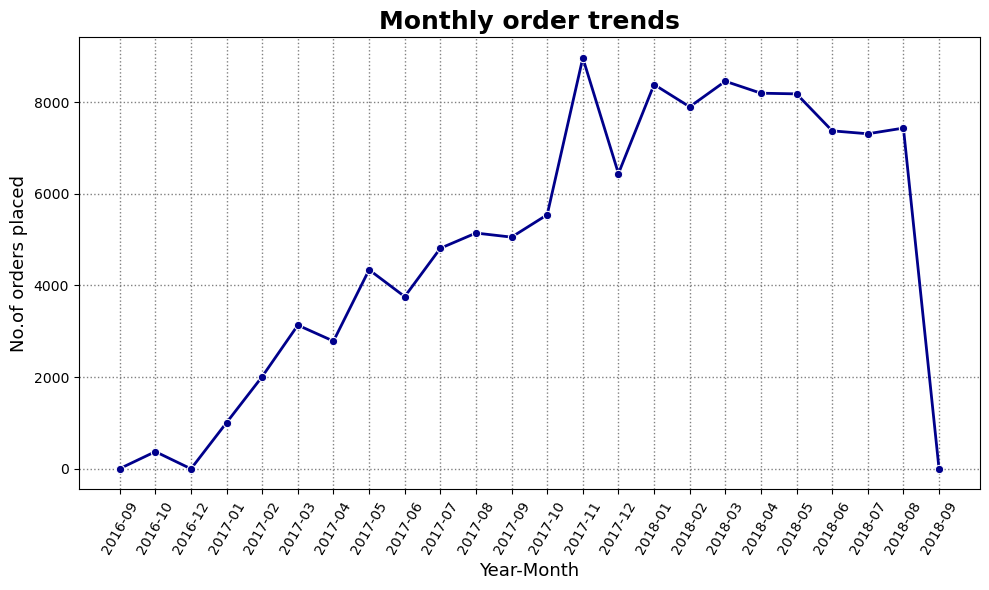

In [172]:
monthly_orders = pd.to_datetime(df['order_purchase_timestamp'])

monthly_orders = monthly_orders.dt.to_period('M')

year_month_count = monthly_orders.value_counts().sort_index()

plt.figure(figsize=(10,6))
sns.lineplot(x=year_month_count.index.astype(str), y=year_month_count.values, color='darkblue', marker='o', linewidth=2)
plt.tick_params(axis='x', labelsize=10, rotation=60)
plt.tick_params(axis='y', labelsize=10)
plt.title('Monthly order trends', fontsize=18, weight='bold')
plt.xlabel('Year-Month', fontsize=13)
plt.ylabel('No.of orders placed', fontsize=13)
plt.grid(color='gray', linestyle=':', linewidth=1)
plt.tight_layout()
plt.savefig('1_monthly_order_trends.png', dpi=300, bbox_inches='tight')
plt.show()


In [173]:
## Insights:-
 # 1) The rise in 2016-09 and fall in 2016-12 suggests the platform was not launched properly, that's why orders 
 #    increased a little bit and then droped to 0

 # 2) The sharp rise from 0 in 2016-12 to more than 2500 orders in 2017-03 shows the platform was launched properly during this time

 # 3) 2017-11 got the highest no.of orders placed in the platform 

 # 4) From 2018-01 to 2018-05, orders were consistently high, nearly 8000 orders per month

 # 5) The sharp drop from 2018-08 is beacuse of incomplete dataset

## 2. Yearly Order trends

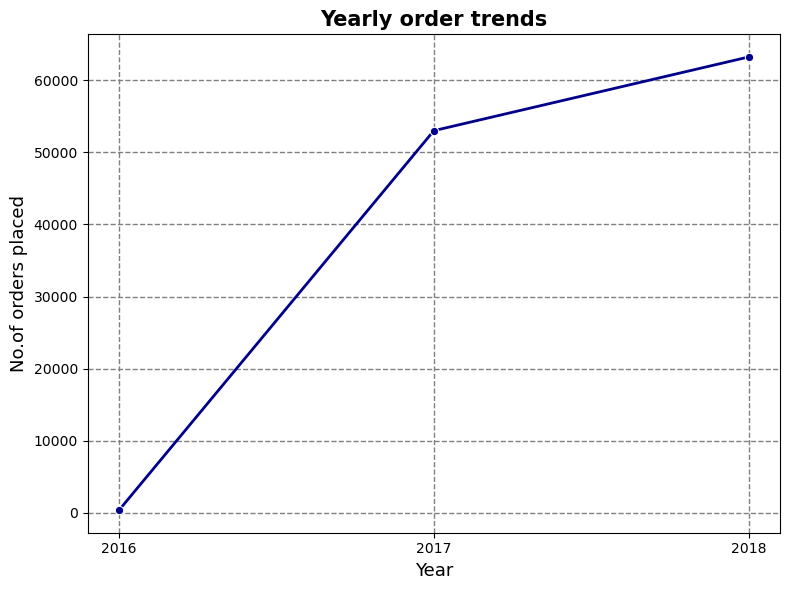

In [174]:
year_orders = pd.to_datetime(df['order_purchase_timestamp'])

year_orders = year_orders.dt.year

year_order_counts = year_orders.value_counts().sort_index()

plt.figure(figsize=(8,6))
sns.lineplot(x=year_order_counts.index.astype(str), y=year_order_counts.values, color = 'darkblue', marker='o', linewidth=2)
plt.title('Yearly order trends', fontsize=15, weight='bold')
plt.tick_params(axis='x', labelsize=10)
plt.tick_params(axis='y', labelsize=10)
plt.xlabel('Year', fontsize=13)
plt.ylabel('No.of orders placed', fontsize=13)
plt.grid(color='gray', linestyle='--', linewidth=1)
plt.tight_layout()
plt.savefig('2_yearly_order_trends', dpi=300, bbox_inches='tight')
plt.show()


In [175]:
## Insights:-
 # 1) The platform started in 2016. So, orders were relatively low.

 # 2) From 2016 to 2017, massive growth occured and no.of orders were more than 50,000 

 # 3) From 2017 to 2018, no.of orders kept on increasing - showing expansion in business


## 3. Order Status Distribution

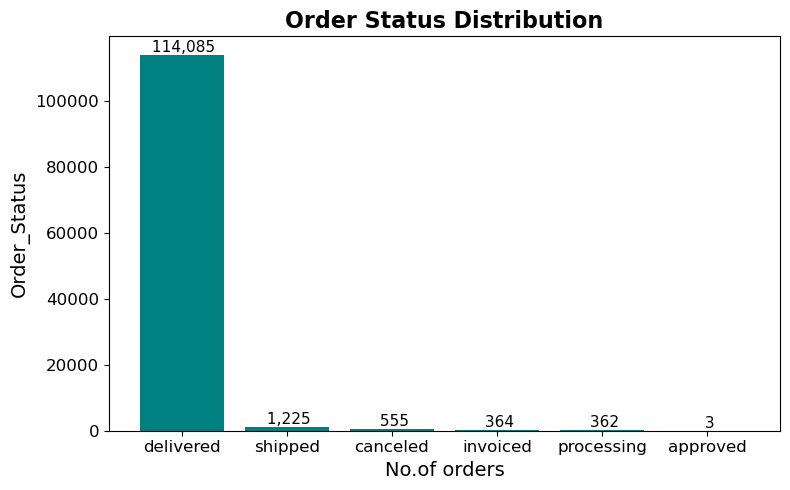

In [176]:
status_counts = df['order_status'].value_counts()

plt.figure(figsize=(8,5))
plt.title('Order Status Distribution', fontsize=16, weight='bold')

plt.bar(status_counts.index, status_counts.values, color='teal')
for i, v in enumerate(status_counts.values):
    plt.text(i, v, f' {v:,}', ha='center', va='bottom', fontsize=11)
    
plt.xlabel('No.of orders', fontsize=14)
plt.ylabel('Order_Status', fontsize=14)
plt.tick_params(axis='x', labelsize=12)
plt.tick_params(axis='y', labelsize=12)
plt.grid(False)
plt.tight_layout()
plt.savefig('3_order_status_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [177]:
## Insights:-
 # 1) 114,085 orders are delivered - showing the platform has high delivery success rate

 # 2) 1,225 orders were in transit when the data was collected 

 # 3) 555 orders are canceled - showing very low cancelation rate and high customer satisfaction

#  4) 364 invoiced orders and 362 processing orders were in pre-shipment stages when the data was collected.

## 4. Peak Ordering Time 

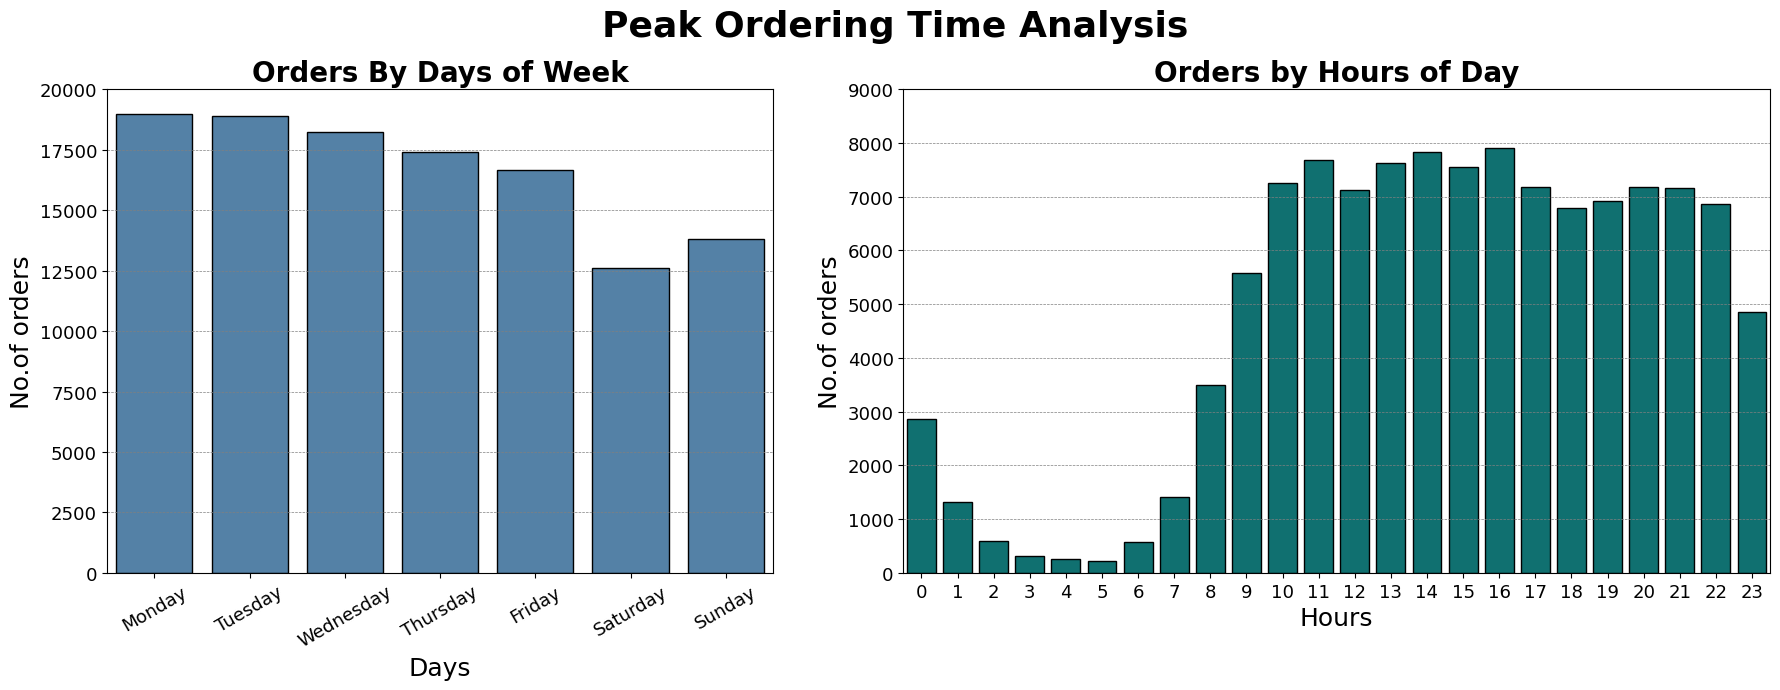

In [178]:
fig, ax = plt.subplots(1,2,figsize=(18,7), gridspec_kw={'width_ratios': [1, 1.3]})
plt.subplots_adjust(top=0.99, left=0.8, wspace=0.8)

d = pd.to_datetime(df['order_purchase_timestamp'])

# Week Days
day_orders = d.dt.day_name()
days = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_orders = day_orders.value_counts().reindex(days)

sns.barplot(x=day_orders.index, 
            y=day_orders.values, 
            color='steelblue', 
            edgecolor='black',
            ax=ax[0])
ax[0].set_title('Orders By Days of Week', fontsize=20, weight='bold')
ax[0].set_xlabel('Days', fontsize=18)
ax[0].set_ylabel('No.of orders', fontsize=18)
ax[0].tick_params(axis='x', rotation=30, labelsize=13)
ax[0].tick_params(axis='y', labelsize=13)
ax[0].set_ylim(0, 20000)
ax[0].grid(axis='y', linestyle='--', color='gray', linewidth=0.5)


# Hours
hours_orders = d.dt.hour
hours_orders = hours_orders.value_counts().sort_index()

sns.barplot(x=hours_orders.index,
            y=hours_orders.values,
            color='teal', 
            edgecolor='black', 
            ax=ax[1])
ax[1].set_title('Orders by Hours of Day', fontsize=20, weight='bold')
ax[1].set_xlabel('Hours', fontsize=18)
ax[1].set_ylabel('No.of orders', fontsize=18)
ax[1].tick_params(axis='x', labelsize=13)
ax[1].tick_params(axis='y', labelsize=13)
ax[1].set_ylim(0, 9000)
ax[1].grid(axis='y', linestyle='--', color='gray', linewidth=0.5)

fig.suptitle('Peak Ordering Time Analysis', fontsize=26, weight='bold')
plt.tight_layout()
plt.savefig('4_Peak_ordering_time_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


In [179]:
## Insights:-
## Days:- 
# 1) Monday and Tuesday has the highest number of orders - indicating customers like to order after the weekend

# 2) No.of orders decreases gradually from Wednesday to Sunday

# 3) Saturday and Sunday have less no.of orders than week days - indicating customers are less likely to shop online on weekends

# 4) Saturday has the least no.of orders - indicating customers prefer leisure activities over online shopping in the weekends

#Hours:-
#  1) No.of orders are very low from 2am to 6am beacuse this is the sleep time for most of the people

#  2) No.of orders start increasing from 6am 

 # 3) 11am to 4pm is the peak time of ordering

 # 4) 4pm has the highest no.of orders - indicating people order towards the end of work hours 

#  5) From 5pm to 7pm, no.of order decreases - showing people wind down after work 

#  6) From 8pm to 9pm, no.of orders slightly increases - showing people are recharged and are back to online shopping

#  7) After 9pm, no.of orders starts decreasing as it is the dinner and bed time for most of the people

# Product Analysis

## 1. Top 10 Product Category 

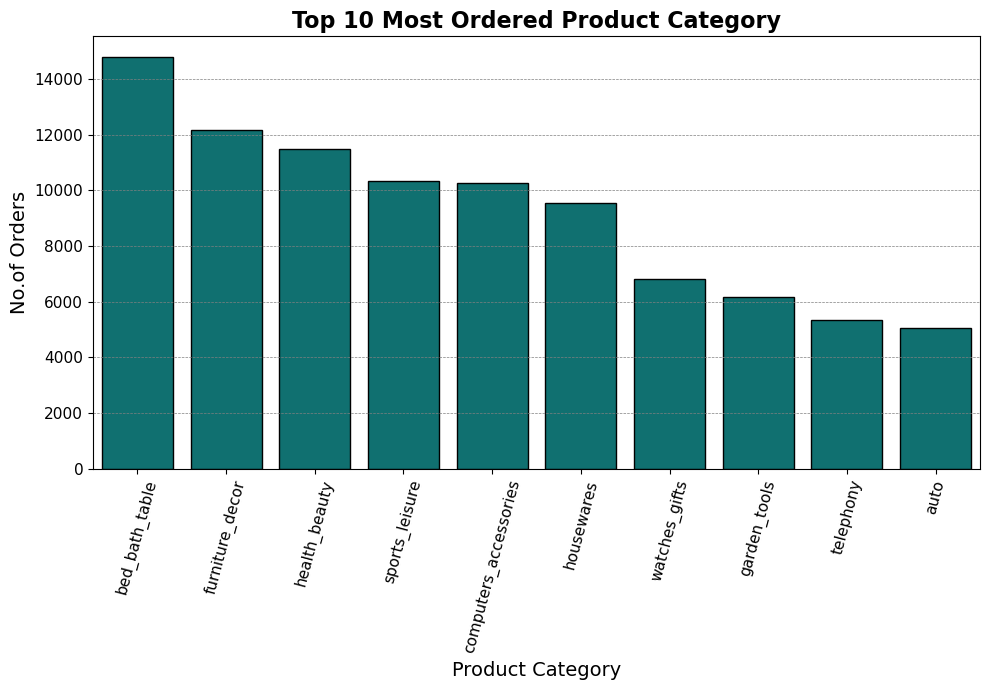

In [180]:
d = df.groupby('product_category_name_english')['order_item_id'].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(10,7))
sns.barplot(x=d['product_category_name_english'],
            y=d['order_item_id'], 
            color='teal',
            edgecolor='black')
# for i, v in enumerate(d['order_item_id']):
#     plt.text(i, v + 100, f'{v:,}', ha='center', va='bottom', fontsize=9)
    
plt.title('Top 10 Most Ordered Product Category', fontsize=16, weight='bold')
plt.xlabel('Product Category', fontsize=14)
plt.ylabel('No.of Orders', fontsize=14)
plt.tick_params(axis='x', labelsize=11, rotation=75)
plt.tick_params(axis='y', labelsize=11)
plt.grid(axis='y', linestyle='--', color='gray', linewidth=0.5)
plt.tight_layout()
plt.savefig('5_Top_10_ordered_product.png', dpi=300, bbox_inches='tight')
plt.show()

In [181]:
##Insights:-
#  1) bed_bath_table and furniture_decor have the highest and second highest no.of orders respectively - indicating customers
#     frequently purchase home essentials online

#  2) health_beauty has the third highest no.of orders - indicating growing trend of online beauty shopping

#  3) computers_accessories shows strong demand for tech products

#  4) The top 5 categories all have 10,000+ orders - showing consistent demand

#  5) Home & lifestyle categories (bed_bath_table, health_beauty, furniture_decor) dominate - suggesting customers primarily 
#    use this platform for household and personal care needs.

## 2. Top 10 most reviewed Product category

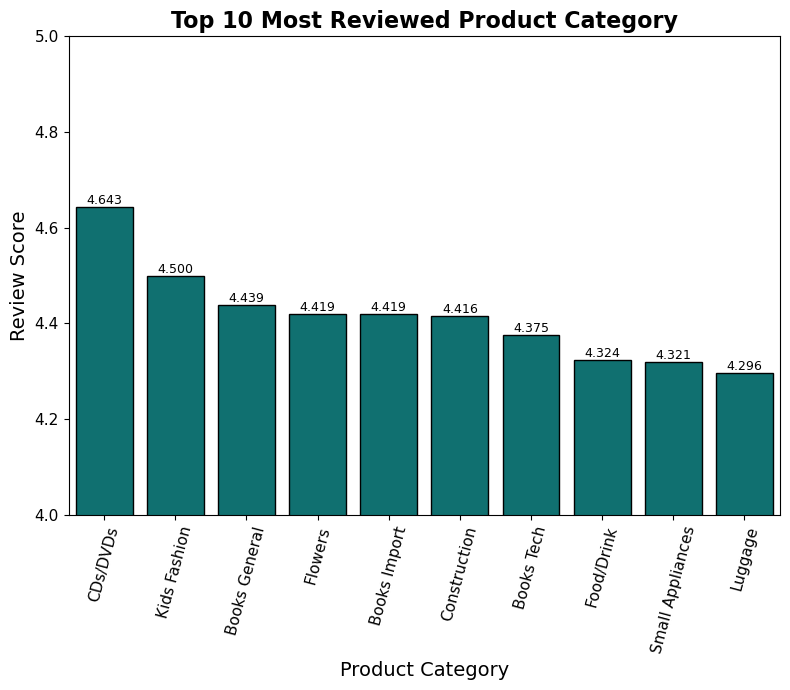

In [182]:
d = df.groupby('product_category_name_english')['review_score'].mean().sort_values(ascending=False).head(10).reset_index()

rename_map = {
    'cds_dvds_musicals': 'CDs/DVDs',
    'fashion_childrens_clothes': 'Kids Fashion',
    'books_general_interest': 'Books General',
    'costruction_tools_tools': 'Construction',
    'flowers': 'Flowers',
    'food_drink': 'Food/Drink',
    'books_imported': 'Books Import',
    'books_technical': 'Books Tech',
    'luggage_accessories': 'Luggage',
    'small_appliances_home_oven_and_coffee': 'Small Appliances'
}
d['product_category_name_english'] = d['product_category_name_english'].map(lambda x: rename_map.get(x, x))


plt.figure(figsize=(8,7))
sns.barplot(x=d['product_category_name_english'],
            y=d['review_score'], 
            color='teal',
            edgecolor='black')
for i, v in enumerate(d['review_score']):
    plt.text(i, v , f'{v:.3f}', ha='center', va='bottom', fontsize=9)
    
plt.title('Top 10 Most Reviewed Product Category', fontsize=16, weight='bold')
plt.xlabel('Product Category', fontsize=14)
plt.ylabel('Review Score', fontsize=14)
plt.tick_params(axis='x', labelsize=11, rotation=75)
plt.tick_params(axis='y', labelsize=11)
plt.ylim(4,5)
plt.tight_layout()
plt.savefig('6_Top_10_most_reviewed_product.png', dpi=300, bbox_inches='tight')
plt.show()

In [183]:
## Insights - Top 10 Most Reviewed Products:
#  1) CDs/DVDs has the highest review score - indicating customers are very satisfied with media products

#  2) Kids Fashion is second - showing high satisfaction with children's clothing

#  3) All top 10 categories have scores above 4.2 - indicating overall high customer satisfaction across the platform

#  4) The difference between highest (4.643) and lowest (4.296) is only 0.347 - showing consistent quality across categories

#  5) Books (General, Import, Technical) appear 3 times in top 10 - suggesting customers are very satisfied with book purchases

## 3. Top 10 Product Categories By Revenue

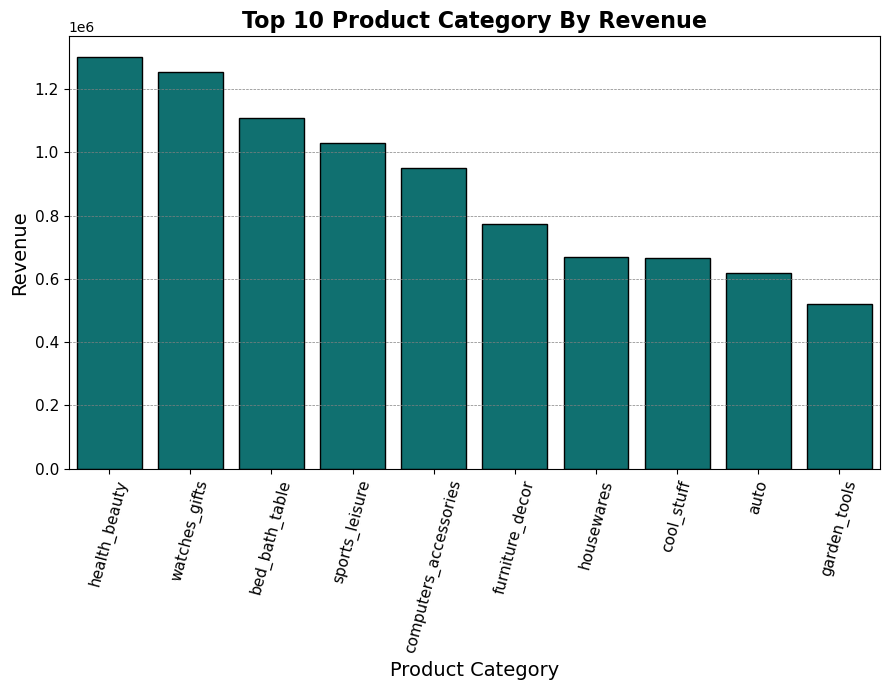

In [184]:
d = df.groupby('product_category_name_english')['price'].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(9,7))
sns.barplot(x=d['product_category_name_english'],
            y=d['price'], 
            color='teal',
            edgecolor='black')
   
plt.title('Top 10 Product Category By Revenue', fontsize=16, weight='bold')
plt.xlabel('Product Category', fontsize=14)
plt.ylabel('Revenue', fontsize=14)
plt.tick_params(axis='x', labelsize=11, rotation=75)
plt.tick_params(axis='y', labelsize=11)
plt.grid(axis='y', linestyle='--', color='gray', linewidth=0.5)
plt.tight_layout()
plt.savefig('7_Top_10_revenue_product.png', dpi=300, bbox_inches='tight')
plt.show()

In [185]:
## Insights - Top 10 Product Categories by Revenue:-
#  1) health_beauty generates the highest revenue, despite being 3rd in top 10 orders — indicating higher priced products

#  2) watches_gifts is 2nd in revenue, but was 7th in top 10 orders - confirming it has high priced items

#  3) bed_bath_table is 3rd in revenue and also 1st in top 10 orders - showing both high sales and decent pricing

#  4) cool_stuff appears in revenue top 10 but was not in top 10 orders - suggesting it has fewer but expensive orders

## 4. Top 10 Average price of Product Categories

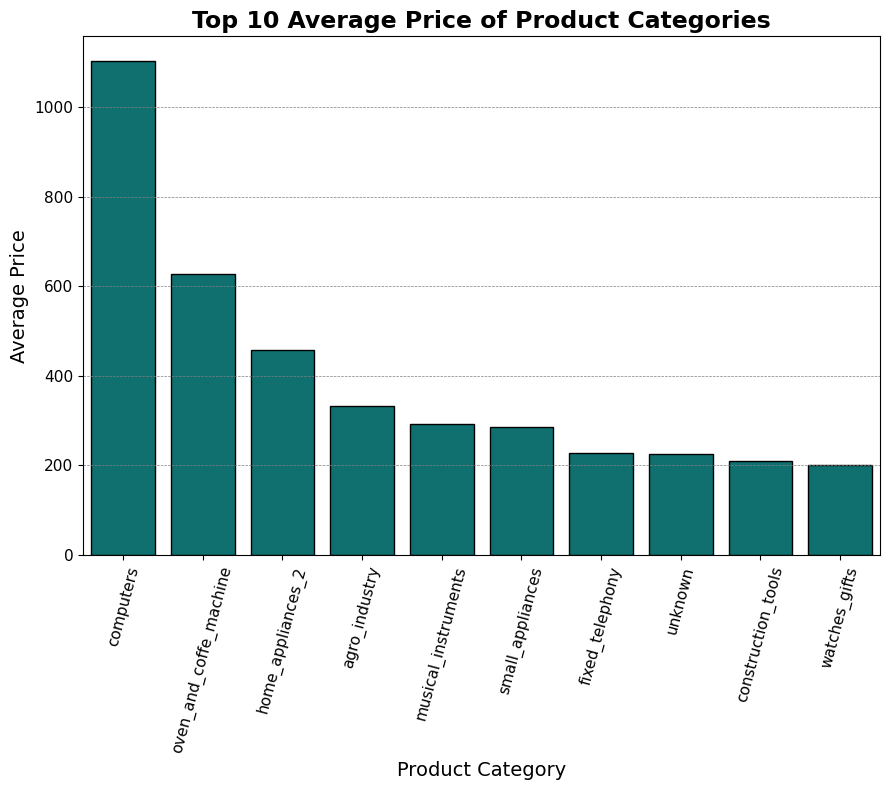

In [186]:
d = df.groupby('product_category_name_english')['price'].mean().sort_values(ascending=False).head(10).reset_index()

rename_map = { 
    'small_appliances_home_oven_and_coffee': 'oven_and_coffe_machine',
    'agro_industry_and_commerce': 'agro_industry',
    'construction_tools_safety': 'construction_tools'
}
d['product_category_name_english'] = d['product_category_name_english'].map(lambda x: rename_map.get(x, x))


plt.figure(figsize=(9,8))
sns.barplot(x=d['product_category_name_english'],
            y=d['price'], 
            color='teal',
            edgecolor='black')
    
plt.title('Top 10 Average Price of Product Categories', fontsize=17, weight='bold')
plt.xlabel('Product Category', fontsize=14)
plt.ylabel('Average Price', fontsize=14)
plt.tick_params(axis='x', labelsize=11, rotation=75)
plt.tick_params(axis='y', labelsize=11)
plt.grid(axis='y', linestyle='--', color='gray', linewidth=0.5)
plt.tight_layout()
plt.savefig('8_Top_10_average_price_product.png', dpi=300, bbox_inches='tight')
plt.show()

In [187]:
## Insights:-

#  1) Computers has the highest average price — indicating customers spend heavily on tech products

#  2) Oven_and_coffee_machine is in 2nd position — home appliances are premium priced

#  3) 'unknown' category suggests some high-priced products were not properly categorized — data quality issue

#  4) Computers and home appliances are the most expensive categories. Although they don't appear in the top 10 by orders,
#     their high price makes them valuable for revenue. These are good targets for premium marketing campaigns.

## 5. Top 3 Categories By Revenue In Top 3 States

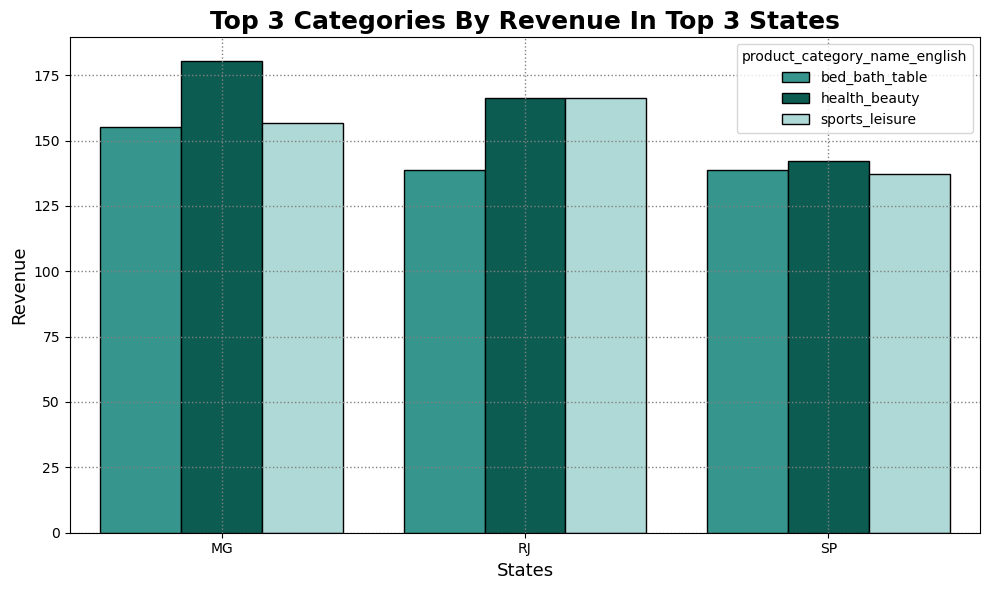

In [188]:
top_states = df['customer_state'].value_counts().index[:3]

top_products = df['product_category_name_english'].value_counts().index[:3]

top_data = df.loc[ (df['customer_state'].isin(top_states)) & (df['product_category_name_english'].isin(top_products)) ]

comparison = top_data.groupby(['customer_state', 'product_category_name_english'])['payment_value'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=comparison,
            x='customer_state',
            y='payment_value',
            hue='product_category_name_english',
            palette=['#26A69A','#00695C', '#A8E0DC'],
            edgecolor='black') 

plt.tick_params(axis='x', labelsize=10)
plt.tick_params(axis='y', labelsize=10)
plt.title('Top 3 Categories By Revenue In Top 3 States', fontsize=18, weight='bold')
plt.xlabel('States', fontsize=13)
plt.ylabel('Revenue', fontsize=13)
plt.grid(color='gray', linestyle=':', linewidth=1)
plt.tight_layout()
plt.savefig('22_Top_3_Categories_By_Revenue_In_Top_3_States.png', dpi=300, bbox_inches='tight')
plt.show()


In [189]:
## Insights:-

#  1) health_beauty leads revenue in MG (more than 175) and RJ (more than 150) — it is the most purchased and highest earning category
#    in these two states consistently.

#  2) All 3 categories perform very similarly in SP — SP is so large that revenue is spread evenly across categories.

#  3) bed_bath_table and sports_leisure are close competitors across all 3 states — neither category has a clear advantage suggesting 
#     customers treat them interchangeably.


# Customer Analysis

## 1. Top 10 Cities and States

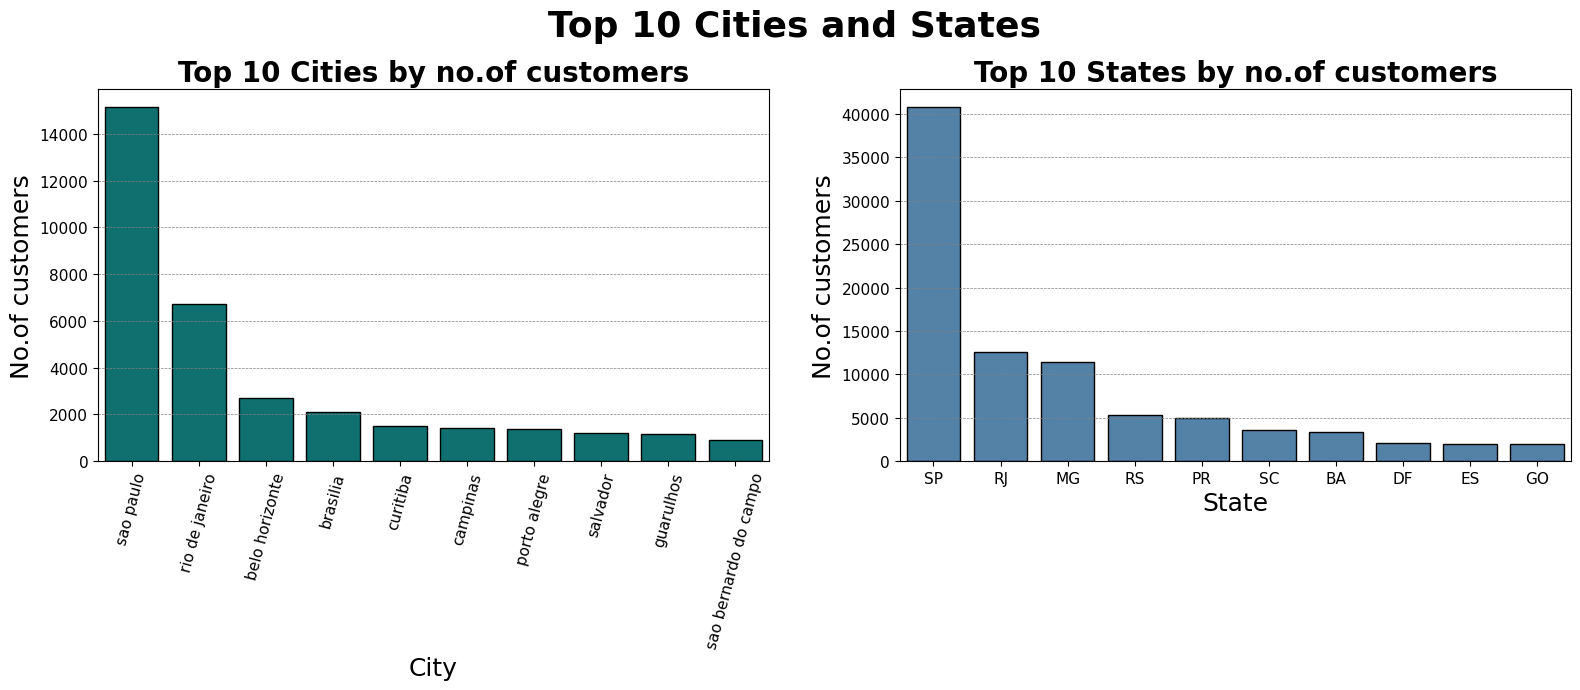

In [190]:
fig, ax = plt.subplots(1,2,figsize=(16,7))
plt.subplots_adjust(top=0.99, left=0.8, wspace=0.8)

# #City
d = df.groupby('customer_city')['customer_id'].nunique().sort_values(ascending=False).head(10).reset_index()
sns.barplot(x=d['customer_city'], 
            y=d['customer_id'], 
            color='teal', 
            edgecolor='black',
            ax=ax[0])
ax[0].set_title('Top 10 Cities by no.of customers', fontsize=20, weight='bold')
ax[0].set_xlabel('City', fontsize=18)
ax[0].set_ylabel('No.of customers', fontsize=18)
ax[0].tick_params(axis='x', rotation=75, labelsize=11)
ax[0].tick_params(axis='y', labelsize=11)
ax[0].grid(axis='y', linestyle='--', color='gray', linewidth=0.5)


# Hours
d = df.groupby('customer_state')['customer_id'].nunique().sort_values(ascending=False).head(10).reset_index()
sns.barplot(x=d['customer_state'], 
            y=d['customer_id'], 
            color='steelblue', 
            edgecolor='black',
            ax=ax[1])
ax[1].set_title('Top 10 States by no.of customers', fontsize=20, weight='bold')
ax[1].set_xlabel('State', fontsize=18)
ax[1].set_ylabel('No.of customers', fontsize=18)
ax[1].tick_params(axis='x', labelsize=11)
ax[1].tick_params(axis='y', labelsize=11)
ax[1].grid(axis='y', linestyle='--', color='gray', linewidth=0.5)

fig.suptitle('Top 10 Cities and States', fontsize=26, weight='bold')
plt.tight_layout()
plt.savefig('9_Top_10_cities_states.png', dpi=300, bbox_inches='tight')
plt.show()


In [191]:
## Insights:-
## Cities:-
#  1) Sao Paulo (Brazil's largest city) has the highest no.of customers

#  2) Rio de Janeiro is 2nd number — huge gap compared to Sao Paulo

## States:-
#  1) SP dominates with more than 40,000 customers — nearly 3 times more than 2nd place,i.e RJ

#  2) SP, RJ, MG together account for majority of all customers

#  3) Business is heavily concentrated in Southeast Brazil (SP, RJ, MG) — marketing efforts should focus on these states for maximum reach

## 2. Repeat Vs One time customers

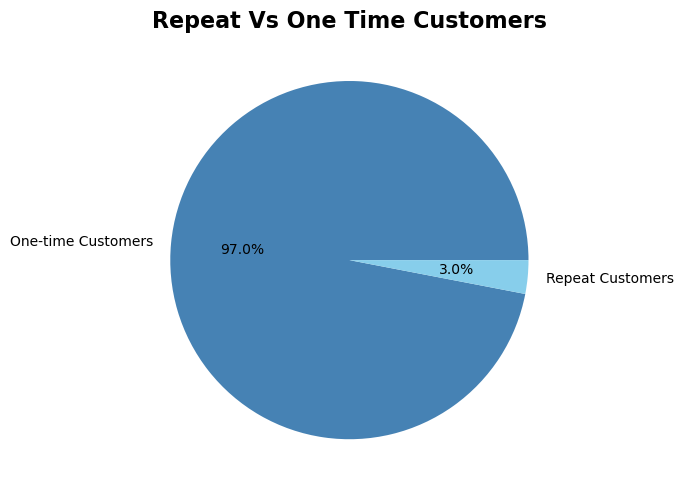

In [192]:
customers = df.groupby('customer_unique_id')['order_id'].nunique()


repeat = (customers > 1).sum()
one_time = (customers == 1).sum()

plt.figure(figsize=(6.5,6))
plt.title('Repeat Vs One Time Customers', fontsize=16, weight='bold')
plt.pie([one_time, repeat], labels=['One-time Customers','Repeat Customers'], autopct='%1.1f%%', colors=['steelblue', 'skyblue'])
plt.tight_layout()
plt.savefig('10_repeat_one_customers.png', dpi=300, bbox_inches='tight')
plt.show()

In [193]:
##Insights:-

# 1) About 97% of customers purchased only once, indicating that most users do not return for another purchase

# 2) Only 3% of customers are repeat customers, which suggests weak customer retention

# 3) Since almost all purchases come from one-time buyers, the business currently relies more on acquiring new customers

# 4) The company needs to work on personalized recommendations, discounts for every customer such that they return after one time purchase

# Delivery Analysis

## 1. Delivery Time in days

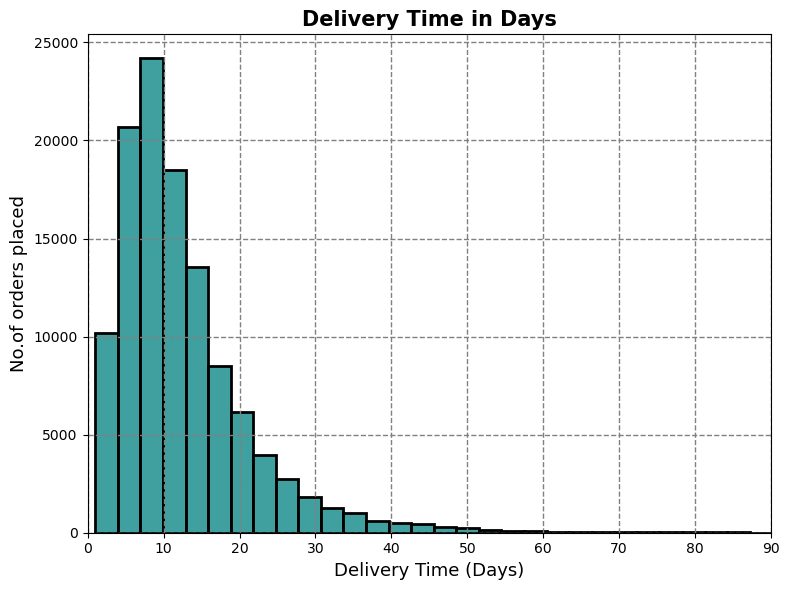

In [194]:
d_delivery = pd.to_datetime(df['order_delivered_customer_date'], errors='coerce')
d_purchase = pd.to_datetime(df['order_purchase_timestamp'], errors='coerce')

delivery_time = (d_delivery - d_purchase).dt.days
delivery_time = delivery_time[delivery_time > 0].dropna()

plt.figure(figsize=(8,6))
sns.histplot(delivery_time, bins=70, color = 'teal', edgecolor='black', linewidth=2)
plt.title('Delivery Time in Days', fontsize=15, weight='bold')
plt.tick_params(axis='x', labelsize=10)
plt.tick_params(axis='y', labelsize=10)
plt.xlabel('Delivery Time (Days)', fontsize=13)
plt.ylabel('No.of orders placed', fontsize=13)
plt.grid(color='gray', linestyle='--', linewidth=1)
plt.xlim(0,90)
plt.tight_layout()
plt.savefig('11_delivery_time_days.png', dpi=300, bbox_inches='tight')
plt.show()


In [195]:
##Insights:-

# 1) The distribution peaks around 9-10 days - meaning most orders are delivered within 10 days

# 2) 80% of the orders are delivered within 0–20 days

# 3) The shape is right-skewed - suggesting some orders takes longer delivery time or are delayed. 

## 2. Top 10 Fastest Delivery States

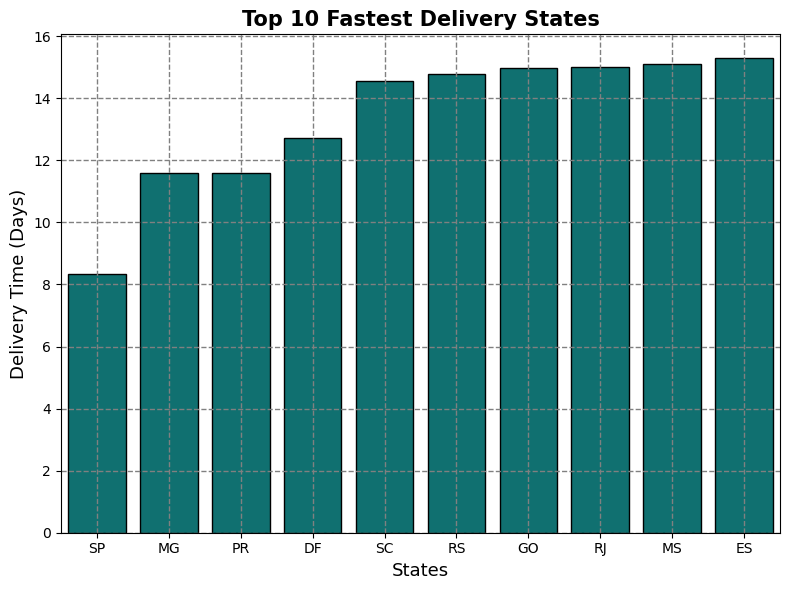

In [196]:
d_delivery = pd.to_datetime(df['order_delivered_customer_date'], errors='coerce')
d_purchase = pd.to_datetime(df['order_purchase_timestamp'], errors='coerce')

delivery_time = (d_delivery - d_purchase).dt.days   # it is a series
delivery_time = delivery_time[delivery_time > 0].dropna()

states = df.loc[delivery_time.index, 'customer_state']  # it is a series

region = pd.concat([delivery_time, states], axis=1)  # it is a dataframe (pd.concat converts it to dataframe)
region.columns = ['delivery_time', 'customer_state']

region = region.groupby('customer_state')['delivery_time'].mean().sort_values(ascending=True).head(10)

plt.figure(figsize=(8,6))
sns.barplot(x=region.index, y=region.values, color = 'teal', edgecolor='black')
plt.title('Top 10 Fastest Delivery States', fontsize=15, weight='bold')
plt.tick_params(axis='x', labelsize=10)
plt.tick_params(axis='y', labelsize=10)
plt.ylabel('Delivery Time (Days)', fontsize=13)
plt.xlabel('States', fontsize=13)
plt.grid(color='gray', linestyle='--', linewidth=1)
plt.tight_layout()
plt.savefig('12_top_10_fastest_delivery_states.png', dpi=300, bbox_inches='tight')
plt.show()


In [197]:
## Business Insights :-

#  1) None of the states in the top 10 delivers under 8 days — this means even the best performing states do not have 7 days delivery facility
#    that customers increasingly expect from e-commerce platforms

#  2) States ranked 7-10 (GO, RJ, MS, ES) all deliver in almost the same time (~15 days) — fixing logistics in one of these states could provide
#    a blueprint to improve all four together, saving time and cost for the company

#  3) With average delivery even in top states exceeding 8 days, customer satisfaction would be low - faster delivery is directly 
#     linked to higher review scores

#  4) Company needs to set a strict 7-day delivery scheme as a target to grow their business.

## 3. Orders delivered before/on/after estimated delivery date

  delivery_status  orders
0          Before  105163
1         On-Time    2705
2           After    7441


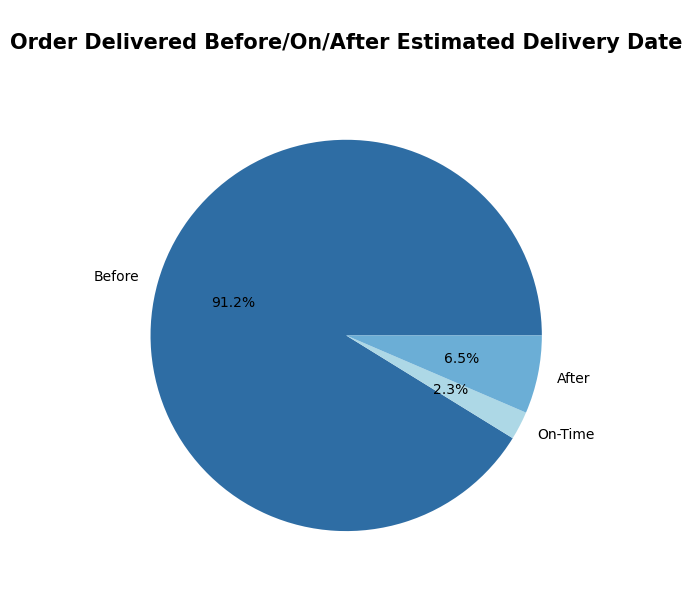

In [198]:
d_estimate = pd.to_datetime(df['order_estimated_delivery_date'], errors='coerce')
d_delivery = pd.to_datetime(df['order_delivered_customer_date'], errors='coerce')

diff = (d_delivery - d_estimate).dt.days

before = diff[diff < 0]

on = diff[diff == 0]

after = diff[diff > 0]

data = pd.DataFrame({
    'delivery_status' : ['Before', 'On-Time', 'After'],
    'orders' : [len(before), len(on), len(after)]
})
print(data)

plt.figure(figsize=(6.5,6))
plt.title('\nOrder Delivered Before/On/After Estimated Delivery Date', fontsize=15, weight='bold', pad=30)

plt.pie(data['orders'], 
        labels=data['delivery_status'], 
        autopct='%1.1f%%',
        colors=['#2E6DA4','lightblue','#6BAED6'])

plt.tight_layout()
plt.savefig('13_before_on_after_estimated_delivery_date.png', dpi=300, bbox_inches='tight')
plt.show()

In [199]:
## Insights:-

#  1) 91.2% of orders are delivered BEFORE the estimated date — this means Company is setting longer estimated dates than needed,
#    a strategy called "under-promise, over-deliver" that keeps customers happy and reduces complaints.

#  2) Only 6.5% of orders arrive AFTER the estimated date — this represents thousands of orders that likely resulted in
#    negative reviews and customer dissatisfaction. 

# 3) Only 2.3% of orders arrive exactly on the estimated date — this means company is giving customers a much later delivery date
#    than actually needed, so that customers will trust the platform more and know exactly when to expect their order.

# 4) The Company could actively promote "delivers earlier than expected" as a selling point to attract new customers and retain existing ones.

# 5) The Company needs to give attention to the 6.5% late delivery rate as even a small percentage of unhappy customers can significantly damage
##  ratings and brand reputation on the platform.

## 4. Average Delivery time by Order Status

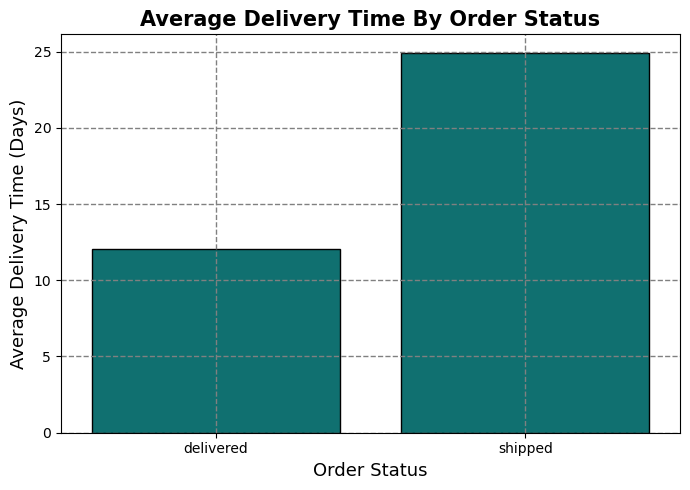

In [200]:
d_delivery = pd.to_datetime(df['order_delivered_customer_date'], errors='coerce')
d_purchase = pd.to_datetime(df['order_purchase_timestamp'], errors='coerce')

delivery_time = (d_delivery - d_purchase).dt.days
delivery_time = delivery_time[delivery_time > 0].dropna()

status = df.loc[delivery_time.index, 'order_status']

comparison = pd.concat([delivery_time, status], axis=1)
comparison.columns = ['delivery_time', 'order_status']
comparison = comparison[~comparison['order_status'].isin(['canceled'])]

comparison = comparison.groupby('order_status')['delivery_time'].mean()

plt.figure(figsize=(7, 5))
sns.barplot(x=comparison.index, y=comparison.values, color='teal', edgecolor='black')
plt.title('Average Delivery Time By Order Status', fontsize=15, weight='bold')
plt.tick_params(axis='x', labelsize=10)
plt.tick_params(axis='y', labelsize=10)
plt.ylabel('Average Delivery Time (Days)', fontsize=13)
plt.xlabel('Order Status', fontsize=13)
plt.grid(color='gray', linestyle='--', linewidth=1)
plt.tight_layout()
plt.savefig('14_Average_Delivery_Time_By_Order_Status.png', dpi=300, bbox_inches='tight')
plt.show()

In [201]:
## Insights:-

#  1) Delivered orders average ~12 days while shipped orders average ~25 days — shipped orders are taking more than 
#     double the time of delivered ones, suggesting these orders are stuck in transit for unusually long periods.

#  2) The 13 day gap between shipped and delivered is a serious red flag — orders that are "shipped" but not yet delivered are likely
#    to get cancelled by customers because of late delivery.

#  3) Shipped orders get delivered at around 25 days, this drops customer satisfaction as customers expect delivery within 2 weeks maximum.


## 5. Distance Vs Delivery Time Vs Review Score

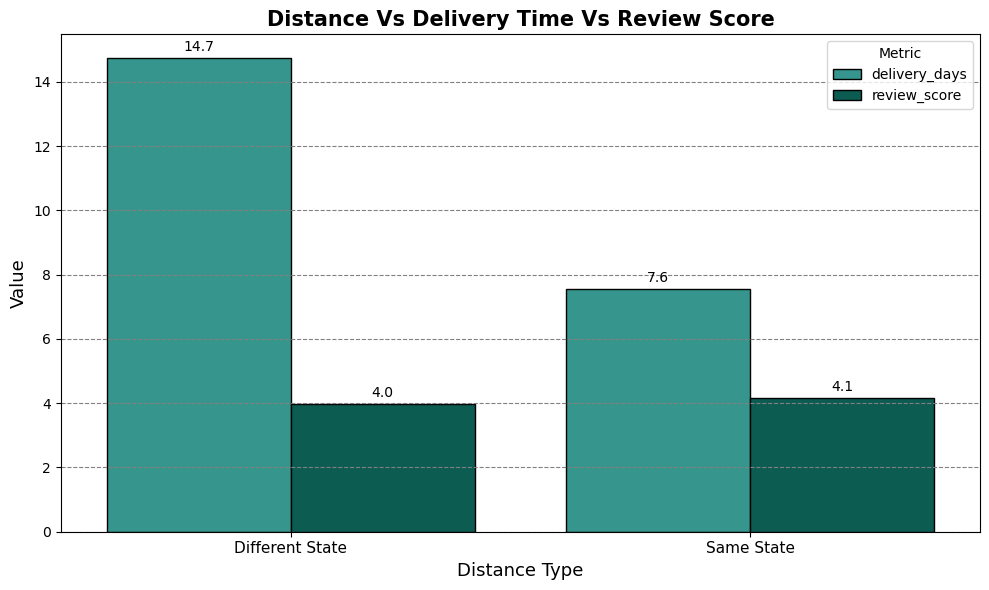

In [232]:
d_delivery = pd.to_datetime(df['order_delivered_customer_date'], errors='coerce')
d_purchase = pd.to_datetime(df['order_purchase_timestamp'], errors='coerce')
delivery_days= (d_delivery - d_purchase).dt.days

distance_type = df.apply(lambda x: 'Same State' 
                                if x['seller_state'] == x['customer_state'] 
                                else 'Different State', axis=1)

review_score = df.loc[delivery_days.index, 'review_score']

comparison = pd.concat([delivery_days, distance_type, review_score], axis=1)
comparison.columns = ['delivery_days', 'distance_type', 'review_score']
comparison = comparison.groupby('distance_type')[['delivery_days', 'review_score']].mean().reset_index()


d_melted = comparison.melt(id_vars='distance_type',
                           value_vars=['delivery_days', 'review_score'],
                           var_name='metric',
                           value_name='value')

plt.figure(figsize=(10, 6))

sns.barplot(data=d_melted,
            x='distance_type',
            y='value',
            hue='metric',
            palette=['#26A69A','#00695C'],
            edgecolor='black')

for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.1f', fontsize=10, padding=3)

plt.title('Distance Vs Delivery Time Vs Review Score', fontsize=15, weight='bold')
plt.tick_params(axis='x', labelsize=11)
plt.tick_params(axis='y', labelsize=10)
plt.xlabel('Distance Type', fontsize=13)
plt.ylabel('Value', fontsize=13)
plt.legend(title='Metric', fontsize=10)
plt.grid(axis='y', linestyle='--', color='gray')
plt.tight_layout()
plt.savefig('23_Distance_Vs_Delivery_Time_Vs_Review_Score.png', dpi=300, bbox_inches='tight')
plt.show()

In [233]:
## Insights:-

#  1) Different state orders take 14.7 days while same state orders take only 7.5 days — orders crossing state boundaries take
#    double the time to deliver compared to local orders.

#  2) Review score drops from 4.1 (same state) to 4.0 (different state) — surprisingly small difference, suggesting customers are somewhat
#    understanding of longer delivery times for distant orders.

#  3) Despite 2x longer delivery time, review score only drops by 0.1  — this means distance alone does not drastically hurt satisfaction, 
#     company's estimation strategy is working well for cross-state orders.

# Review Analysis

## 1. Ditribution of Review score 

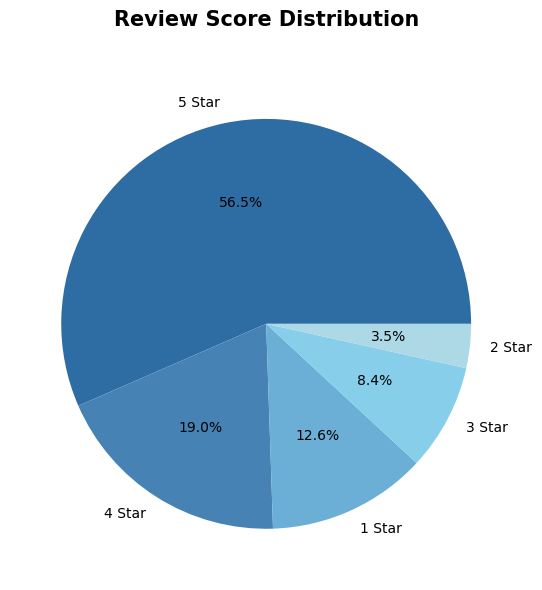

In [202]:
review_counts = df['review_score'].value_counts()
plt.figure(figsize=(6.5,6))

plt.pie(review_counts.values, 
        labels=['5 Star','4 Star','1 Star','3 Star','2 Star'], 
        autopct='%1.1f%%', 
        colors=['#2E6DA4','steelblue','#6BAED6','skyblue','lightblue'])

plt.title('Review Score Distribution', fontsize=15, weight='bold', pad=30)
plt.tight_layout()
plt.savefig('15_review_score_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [203]:
## Insights:-

#  1) 56.5% of customers gave 5 stars — more than half of all customers are highly satisfied, which is a strong indicator that
#    the company's overall product and delivery experience is positive.

#  2) Combined 4 and 5 star reviews make up 75.5% — this means larger portion of the customers are happy with their experience.

#  3) 12.6% of customers gave 1 star - which is concerning because a good portion of customers had bad experience and are likely
#     to give the lowest review score or return the product.

# 4) 2 and 3 star reviews together make up 11.9% — customers are disappointed with the product or delivery.

# 5) The gap between 5 star (56.5%) and 1 star (12.6%) is large but the 1 star percentage is still too high — the company should investigate
#    what drives 1 star reviews (late delivery, wrong product,poor quality) and target to reduce it.


## 2. Price Vs Review Score

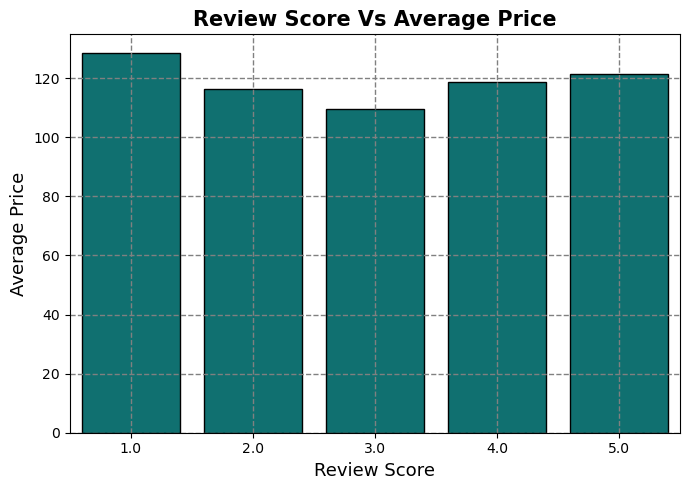

In [204]:
comparison = df.groupby('review_score')['price'].mean().reset_index()

plt.figure(figsize=(7,5))
sns.barplot(x=comparison['review_score'], y=comparison['price'], color = 'teal', edgecolor='black')
plt.title('Review Score Vs Average Price', fontsize=15, weight='bold')
plt.tick_params(axis='x', labelsize=10)
plt.tick_params(axis='y', labelsize=10)
plt.ylabel('Average Price', fontsize=13)
plt.xlabel('Review Score', fontsize=13)
plt.grid(color='gray', linestyle='--', linewidth=1)
plt.tight_layout()
plt.savefig('16_review_score_Vs_average_price.png', dpi=300, bbox_inches='tight')
plt.show()

In [205]:
## Insights:-

#  1) 1 star reviews have the highest average price — customers who spent the most money are the most dissatisfied, meaning
#    expensive products are failing to meet customer expectations.

# 2) 3 star reviews have the lowest average price — suggesting cheap products don't impress customers but also don't disappoint them.

#  3) The difference between highest average price (1 star)  and lowest average price (3 star) is less — suggesting price alone
#     does not fully predict review score. Other factors like delivery time and product quality also play a role.

# 4) 4 and 5 star reviews have similar average prices — suggesting a price range that delivers products that have good value for money.

# 5) The Company should focus on quality checks on higher priced products — since expensive items get the worst reviews.


## 3. Review Score Vs Average Delivery Time

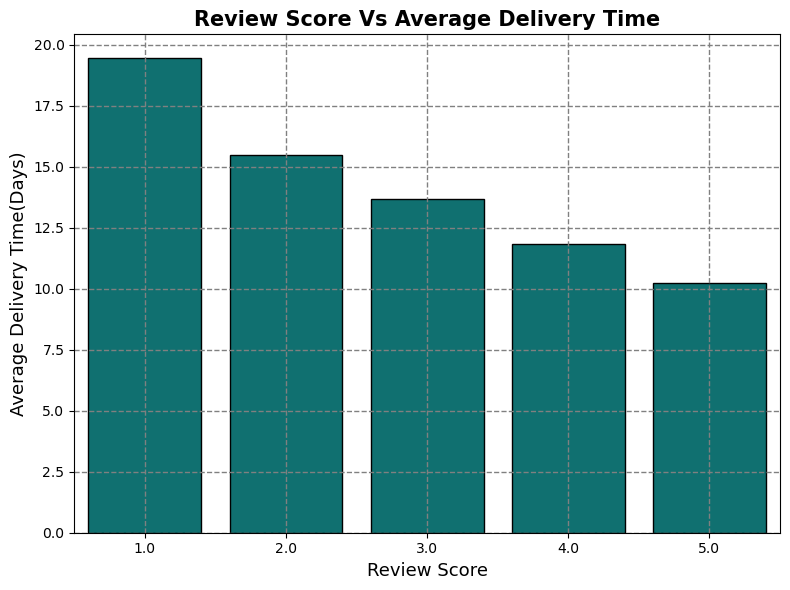

In [206]:
d_delivery = pd.to_datetime(df['order_delivered_customer_date'], errors='coerce')
d_purchase = pd.to_datetime(df['order_purchase_timestamp'], errors='coerce')

delivery_time = (d_delivery - d_purchase).dt.days   # it is a series
delivery_time = delivery_time[delivery_time > 0].dropna()

review = df.loc[delivery_time.index, 'review_score']  # it is a series

comparison = pd.concat([delivery_time, review], axis=1)  # it is a dataframe (pd.concat converts it to dataframe)

comparison.columns = ['delivery_time', 'review_score']

comparison = comparison.groupby('review_score')['delivery_time'].mean()

plt.figure(figsize=(8,6))
sns.barplot(x=comparison.index, y=comparison.values, color = 'teal', edgecolor='black')
plt.title('Review Score Vs Average Delivery Time', fontsize=15, weight='bold')
plt.tick_params(axis='x', labelsize=10)
plt.tick_params(axis='y', labelsize=10)
plt.xlabel('Review Score', fontsize=13)
plt.ylabel('Average Delivery Time(Days)', fontsize=13)
plt.grid(color='gray', linestyle='--', linewidth=1)
plt.tight_layout()
plt.savefig('17_review_score_Vs_Average_delivery_time.png', dpi=300, bbox_inches='tight')
plt.show()

In [207]:
## Insights:-

#  1) As delivery time decreases, review score increases consistently. This is the strongest evidence that
#    delivery time is the biggest driver of customer satisfaction.

#  2) 1 star reviews have nearly 20 days of delivery time while 5 star reviews have nearly 11 days - 9 days difference between 1 star and 
#     5 star deliveries shows that cutting delivery time by nearly 9 days would potentially increase the review score.

# 4) 4 and 5 star reviews both fall under 12.5 days — this confirms that delivering within 12 days is the threshold
#    for earning a positive review from customers.


# Payment Analysis

## 1. Payment type mostly used 

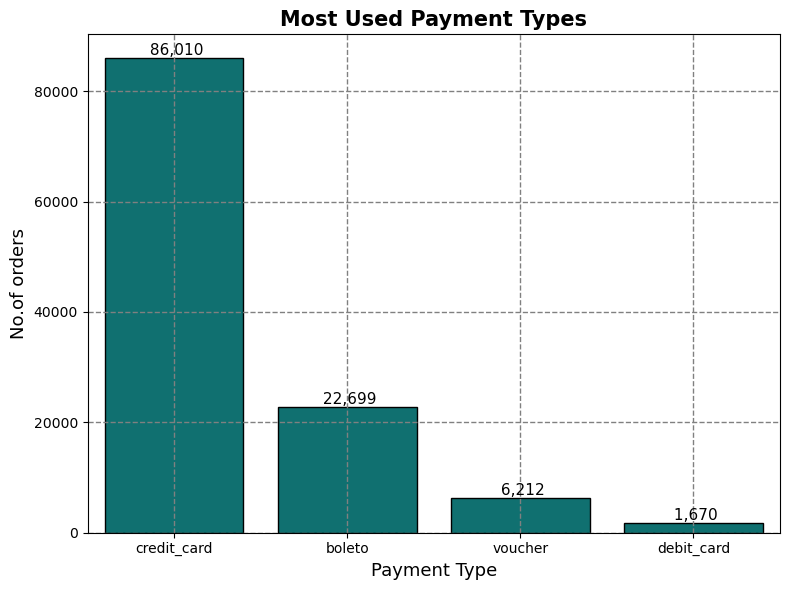

In [208]:
payment_counts = df['payment_type'].value_counts()

plt.figure(figsize=(8,6))

sns.barplot(x=payment_counts.index, y=payment_counts.values, color = 'teal', edgecolor='black')
for i, v in enumerate(payment_counts.values):
    plt.text(i, v, f' {v:,}', ha='center', va='bottom', fontsize=11)
    
plt.title('Most Used Payment Types', fontsize=15, weight='bold')
plt.tick_params(axis='x', labelsize=10)
plt.tick_params(axis='y', labelsize=10)
plt.xlabel('Payment Type', fontsize=13)
plt.ylabel('No.of orders', fontsize=13)
plt.grid(color='gray', linestyle='--', linewidth=1)
plt.tight_layout()
plt.savefig('18_Most_Used_Payment_Types.png', dpi=300, bbox_inches='tight')
plt.show()

In [209]:
## Insights:-

#  1) Credit card dominates with 86,010 orders — customers strongly prefer paying in installments.

#  2) Boleto is second with 22,699 orders  — this is a Brazil-specific payment method showing that a significant portion
#    of customers don't have or trust credit cards for online shopping.

#  3) Debit card is the least used with only 1,670 orders — customers avoid debit cards for online purchases, likely due to
#    security concerns or preference for installment options.

#  4) The low voucher usage (6,212 orders) suggests the company's discount and promotional voucher strategy is not reaching enough customers
#    — a stronger voucher campaign could boost sales significantly.

#  5) The company should start offering better EMI options, zero interest plans, or credit card exclusive deals as credit card
#     is the backbone of payment system for the company.


## 2. Average Payment Installments By Price Range

C:\Users\KIIT0001\AppData\Local\Temp\ipykernel_28424\1228033874.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d['price_range'] = pd.cut(d['price'],


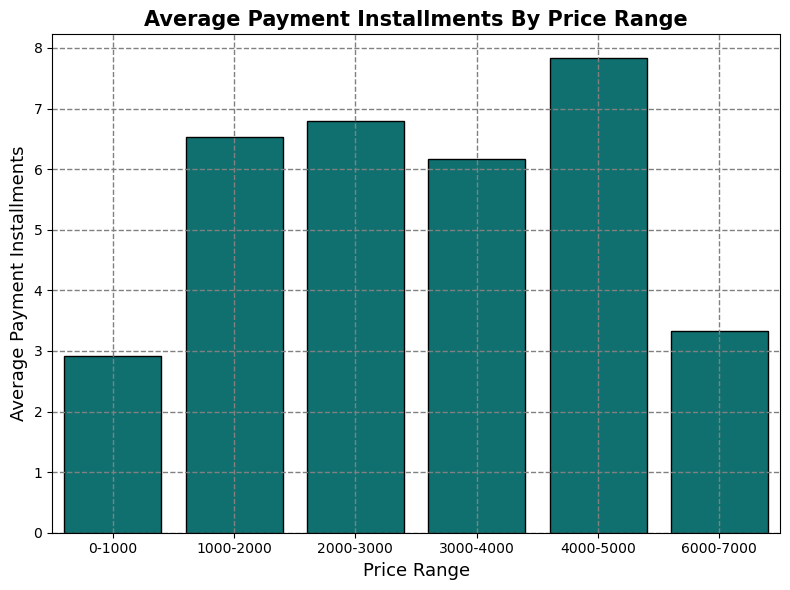

In [210]:
d = df[['payment_installments','price']]

d['price_range'] = pd.cut(d['price'],
                          bins=[0, 1000, 2000, 3000, 4000, 5000, 6000, 7000],
                          labels=['0-1000', '1000-2000', '2000-3000', '3000-4000', '4000-5000', '5000-6000', '6000-7000'])

d = d.groupby('price_range', observed=True)['payment_installments'].mean()
d = d.dropna()

d.index = d.index.astype(str)
d = d[d != 0] 

plt.figure(figsize=(8,6))
sns.barplot(x=d.index, y=d.values, color = 'teal', edgecolor='black')
plt.title('Average Payment Installments By Price Range', fontsize=15, weight='bold')
plt.tick_params(axis='x', labelsize=10)
plt.tick_params(axis='y', labelsize=10)
plt.xlabel('Price Range', fontsize=13)
plt.ylabel('Average Payment Installments', fontsize=13)
plt.grid(color='gray', linestyle='--', linewidth=1)
plt.tight_layout()
plt.savefig('19_Average_payment_installments_by_price_range.png', dpi=300, bbox_inches='tight')
plt.show()

In [211]:
## Insights:-

#  1) Cheapest items (0-1000 price range) have the lowest installments — customers buying low priced items pay quickly in fewer splits.

#  2) Installments generally rise from 0-1000 price range to 4000-5000 price range — the more expensive the product, the customers need to
#    split payments, confirming that EMI is essential for higher purchases.

# 3) 4000-5000 price range has nearly ~7.8 installments — customers are stretching their budget the most here, splitting into
#    almost 8 monthly payments just to afford these products.

# 4) 3000-4000 price range has nearly ~6.2 installments - this suggests fewer customers buy in this price range or they use different
#    payment methods like boleto instead of credit card EMIs.

# 5) 6000-7000 price range drops to nearly 3 installments despite being the most expensive range — only wealthy customers buy here
#    and they can afford to pay in fewer installments or in full.


## 3. Average Payment Value by States

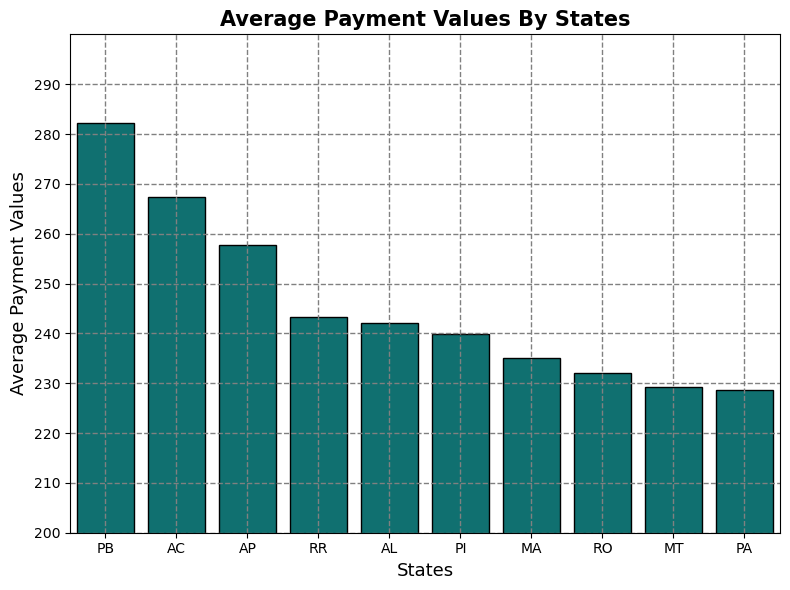

In [212]:
comparison = df.groupby('customer_state')['payment_value'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,6))
sns.barplot(x=comparison.index, y=comparison.values, color = 'teal', edgecolor='black')
plt.title('Average Payment Values By States', fontsize=15, weight='bold')
plt.tick_params(axis='x', labelsize=10)
plt.tick_params(axis='y', labelsize=10)
plt.yticks(range(200,300,10))
plt.xlabel('States', fontsize=13)
plt.ylabel('Average Payment Values', fontsize=13)
plt.ylim(200,300)
plt.grid(color='gray', linestyle='--', linewidth=1)
plt.tight_layout()
plt.savefig('20_Average_payment_values_by_states.png', dpi=300, bbox_inches='tight')
plt.show()

In [213]:
## Insights:-

#  1) PB has the highest average payment value — surprisingly a northeastern state, not a wealthy southeastern
#    state, is spending the most per order.

# 2) Top 3 states (PB, AC, AP) are all from north/northeast Brazil — these are remote states with fewer physical stores, so customers
#    rely more on e-commerce and tend to buy higher value items online.


# Time Analysis

 ## 1. Customer Growth Over Time 

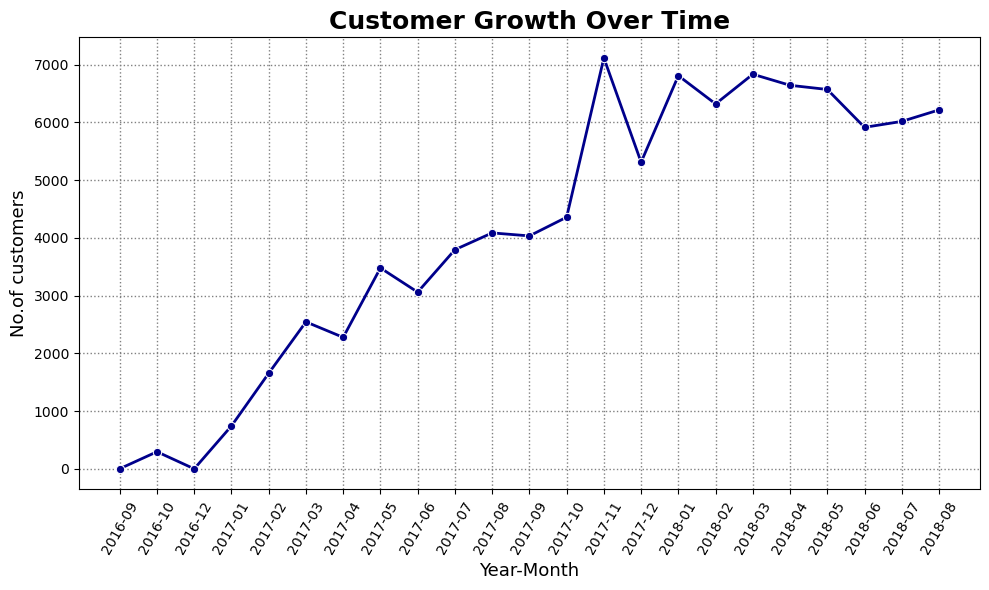

In [214]:
purchase_time = pd.to_datetime(df['order_purchase_timestamp'])

purchase_time = purchase_time.dt.to_period('M')

customer = df.loc[purchase_time.index, ['customer_id','customer_unique_id']]

growth = pd.concat([purchase_time, customer], axis=1)
growth.columns = ['purchase_time', 'customer_id', 'customer_unique_id']
growth = growth.groupby('customer_unique_id')['purchase_time'].min()

growth_counts = growth.value_counts().sort_index()

plt.figure(figsize=(10,6))
sns.lineplot(x=growth_counts.index.astype(str), y=growth_counts.values, color='darkblue', marker='o', linewidth=2)
plt.tick_params(axis='x', labelsize=10, rotation=60)
plt.tick_params(axis='y', labelsize=10)
plt.title('Customer Growth Over Time', fontsize=18, weight='bold')
plt.xlabel('Year-Month', fontsize=13)
plt.ylabel('No.of customers', fontsize=13)
plt.grid(color='gray', linestyle=':', linewidth=1)
plt.tight_layout()
plt.savefig('21_Customer_Growth_Over_Time.png', dpi=300, bbox_inches='tight')
plt.show()

In [215]:
## Insights:-

#  1) Strong overall growth from Dec 2016 to Nov 2017 — new customer grew from nearly 0 to 7000+, showing the company
#    expanded very rapidly in its early stages.

#  2) Nov 2017 has the highest no.of customers — this is likely to coincide with Black Friday 2017, confirming that
#    seasonal sales events attracts more no.of customers.

#  3) 2018 shows a stable no.of customers per month — growth has stabilized meaning the company is no longer in its
#    hyper growth phase and needs new strategies for acquiring new customers.

#  4) The data ends at Aug 2018 with more than 6000 customers — the slight decline from the 2018 peak suggests growth is starting to slow down
#    and acquiring new customers is getting harder and more expensive.
